# 06b - Retrieval Diagnostics

## 0. Obiettivo e criteri

Questo notebook mappa esperimenti retrieval-only per capire quale configurazione porta piu' spesso l'articolo corretto nel candidate set dell'advanced RAG, senza usare la qualita' della risposta finale come proxy.

**Metrica primaria:** `article_hit@k`, cioe' almeno un chunk dell'articolo atteso tra i candidati.

**Metriche secondarie:** `article_mrr`, `law_hit`, `all_expected_articles_hit`, `filter_excluded`, `expansion_noise_ratio`.

**Regola decisionale:** uno scenario e' migliore se aumenta `article_hit` rispetto alla baseline senza introdurre esclusioni sistematiche o rumore eccessivo. L'hybrid retrieval viene usato solo se l'indice corrente espone sparse vectors; altrimenti viene saltato esplicitamente.


## 1. Setup globale

Questa sezione contiene solo parametri, helper visuali e la mappa degli esperimenti. Per una smoke run veloce si puo' impostare la variabile ambiente `RETRIEVAL_DIAGNOSTICS_BENCHMARK_SIZE=10` prima di eseguire il notebook; in assenza di override viene usato `BENCHMARK_SIZE`.


In [1]:
from __future__ import annotations

import itertools
import os
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "legal_rag").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

RUN_NAME = "default"
BENCHMARK_SIZE: int | None = None
_env_benchmark_size = os.environ.get("RETRIEVAL_DIAGNOSTICS_BENCHMARK_SIZE")
if _env_benchmark_size:
    BENCHMARK_SIZE = None if _env_benchmark_size.lower() == "all" else int(_env_benchmark_size)

TOP_K_VALUES = [5, 10, 20, 30, 50, 75, 100]
BASELINE_TOP_K = 10
BUDGET_TOP_K = 20
LOW_NOISE_THRESHOLD = 0.95
PRIMARY_CURRENT_FILTER = "law_status_current"
FILTER_VARIANTS: dict[str, dict[str, Any]] = {
    "none": {},
    "law_status_current": {"law_status": "current"},
    "index_views_current": {"index_views": "current"},
    "article_status_current": {"article_status": "current"},
}
GRAPH_SEED_K_VALUES = [1, 2, 3]
MAX_CHUNKS_PER_EXPANDED_LAW_VALUES = [1, 2, 3]
MIN_EDGE_CONFIDENCE_VALUES = [0.45, 0.6, 0.8]
RELATION_TYPE_VARIANTS: dict[str, list[str]] = {
    "references_only": ["REFERENCES"],
    "modified_by_only": ["MODIFIED_BY"],
    "inserted_by_only": ["INSERTED_BY"],
    "replacement_only": ["REPLACED_BY", "REPLACES"],
    "amendment_only": ["AMENDS", "INSERTS", "MODIFIED_BY", "INSERTED_BY"],
    "default": ["REFERENCES", "AMENDS", "INSERTS", "MODIFIED_BY", "INSERTED_BY"],
}

RUN_RERANK = False
GRAPH_EXPANSION_BACKEND = "in_memory"  # "in_memory" or "qdrant_ranked"
RERANK_QUESTION_SAMPLE = 30
RERANK_INPUT_K = 20
RERANK_OUTPUT_K = 5

PREWARM_QUERY_EMBEDDINGS = True
SHOW_PROGRESS = True

DATASET_SPECS = {
    "no_hint": {"filename": "questions_no_hint.jsonl", "question_key": "question"},
    "mcq": {"filename": "questions_mcq.jsonl", "question_key": "question_stem"},
}

OUTPUT_TIMESTAMP = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
OUTPUT_DIR = PROJECT_ROOT / "data" / "retrieval_eval_runs" / f"{RUN_NAME}__{OUTPUT_TIMESTAMP}"
RERANK_CACHE_PATH = OUTPUT_DIR / "rerank_cache.jsonl"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

print(f"Run output dir: {OUTPUT_DIR}")
print(f"Benchmark size: {BENCHMARK_SIZE if BENCHMARK_SIZE is not None else 'all'}")
print(f"Rerank enabled: {RUN_RERANK}")


Run output dir: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/retrieval_eval_runs/default__20260511T180530Z
Benchmark size: all
Rerank enabled: False


In [2]:
def pct(value: float | int | None) -> str:
    if value is None or pd.isna(value):
        return "n/a"
    return f"{float(value) * 100:.1f}%" if abs(float(value)) <= 1 else f"{float(value):.1f}%"


def display_experiment_card(
    title: str,
    *,
    status: str,
    metric: str | None = None,
    note: str = "",
    config: dict[str, Any] | None = None,
) -> None:
    lines = [f"**{title}**", f"- Stato: `{status}`"]
    if metric:
        lines.append(f"- Metrica primaria: `{metric}`")
    if note:
        lines.append(f"- Nota: {note}")
    if config:
        compact = ", ".join(f"`{key}={value}`" for key, value in config.items())
        lines.append(f"- Parametri: {compact}")
    display(Markdown("\n".join(lines)))


def _ordered_columns(df: pd.DataFrame, preferred: list[str]) -> pd.DataFrame:
    existing = [column for column in preferred if column in df.columns]
    rest = [column for column in df.columns if column not in existing]
    return df[existing + rest]


def _plot_barh_metric(df: pd.DataFrame, *, title: str, metric: str = "article_hit_pct") -> None:
    if df.empty:
        display(Markdown("_Nessun dato da visualizzare._"))
        return
    plot_df = df.copy()
    fig, ax = plt.subplots(figsize=(9, 0.55 * max(len(plot_df), 4)))
    ax.barh(plot_df["scenario_name"], plot_df[metric], color=plot_df.get("color", "#3b82b6"))
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_xlim(0, max(100, float(plot_df[metric].fillna(0).max()) + 5))
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    for index, value in enumerate(plot_df[metric].fillna(0)):
        ax.text(float(value) + 0.5, index, f"{float(value):.1f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()


In [3]:
EXPERIMENT_MAP: list[dict[str, Any]] = [
    {
        "name": "dense_baseline_top10",
        "title": "Baseline dense@10 senza filtro",
        "stage": "direct",
        "primary_metric": "article_hit@10",
        "status": "pending",
        "parameters": {"retrieval_mode": "dense", "top_k": BASELINE_TOP_K, "filter": "none"},
    },
    {
        "name": "dense_topk_curve",
        "title": "Curva dense top-k",
        "stage": "direct",
        "primary_metric": "article_hit@k",
        "status": "pending",
        "parameters": {"retrieval_mode": "dense", "top_k": TOP_K_VALUES, "filter": "none"},
    },
    {
        "name": "best_dense_budget_top20",
        "title": "Best direct con budget top20",
        "stage": "direct",
        "primary_metric": "article_hit@k con k<=20",
        "status": "pending",
        "parameters": {"retrieval_mode": "dense", "top_k_max": BUDGET_TOP_K, "filters": list(FILTER_VARIANTS)},
    },
    {
        "name": "current_law_filter",
        "title": "Filtro law_status=current",
        "stage": "direct",
        "primary_metric": "article_hit@10 - filter_excluded",
        "status": "pending",
        "parameters": {"retrieval_mode": "dense", "top_k": BASELINE_TOP_K, "filter": PRIMARY_CURRENT_FILTER},
    },
    {
        "name": "best_filter_from_sweep",
        "title": "Best filtro metadata dal direct sweep",
        "stage": "direct",
        "primary_metric": "article_hit@10 - filter_excluded",
        "status": "pending",
        "parameters": {"retrieval_mode": "dense", "top_k": BASELINE_TOP_K, "filters": list(FILTER_VARIANTS)},
    },
    {
        "name": "graph_default_seed3",
        "title": "Graph expansion default",
        "stage": "graph",
        "primary_metric": "post_article_hit@10",
        "status": "pending",
        "parameters": {"top_k": BASELINE_TOP_K, "seed_k": 3, "max_chunks_per_law": 2, "min_confidence": 0.45, "relations": "default"},
    },
    {
        "name": "graph_references_only",
        "title": "Graph expansion REFERENCES only",
        "stage": "graph",
        "primary_metric": "post_article_hit@10",
        "status": "pending",
        "parameters": {"top_k": BASELINE_TOP_K, "seed_k": 3, "max_chunks_per_law": 2, "min_confidence": 0.45, "relations": "references_only"},
    },
    {
        "name": "best_graph_from_sweep",
        "title": "Best graph dal sweep",
        "stage": "graph",
        "primary_metric": "post_article_hit - expansion_noise_ratio",
        "status": "pending",
        "parameters": {"search_space": "graph sweep"},
    },
    {
        "name": "best_graph_low_noise",
        "title": "Best graph low-noise",
        "stage": "graph",
        "primary_metric": f"post_article_hit con noise<={LOW_NOISE_THRESHOLD}",
        "status": "pending",
        "parameters": {"max_expansion_noise_ratio": LOW_NOISE_THRESHOLD},
    },
    {
        "name": "hybrid_if_available",
        "title": "Hybrid retrieval se disponibile",
        "stage": "direct",
        "primary_metric": "article_hit@k",
        "status": "pending",
        "parameters": {"retrieval_mode": "hybrid", "top_k": TOP_K_VALUES},
    },
]


def mark_experiment(name: str, *, status: str, reason: str = "", rows: int | None = None, extra: dict[str, Any] | None = None) -> None:
    for experiment in EXPERIMENT_MAP:
        if experiment["name"] == name:
            experiment["status"] = status
            experiment["reason"] = reason
            if rows is not None:
                experiment["rows"] = rows
            if extra:
                experiment.update(extra)
            return
    raise KeyError(name)


def experiment_map_df() -> pd.DataFrame:
    rows = []
    for experiment in EXPERIMENT_MAP:
        row = dict(experiment)
        row["parameters"] = row.get("parameters", {})
        rows.append(row)
    return pd.DataFrame(rows)


display(_ordered_columns(experiment_map_df(), ["name", "stage", "primary_metric", "status", "parameters"]))


,name,stage,primary_metric,status,parameters,title
0,dense_baseline_top10,direct,article_hit@10,pending,"{'retrieval_mode': 'dense', 'top_k': 10, 'filter': 'none'}",Baseline dense@10 senza filtro
1,dense_topk_curve,direct,article_hit@k,pending,"{'retrieval_mode': 'dense', 'top_k': [5, 10, 20, 30, 50, 75, 100], 'filter': 'none'}",Curva dense top-k
2,best_dense_budget_top20,direct,article_hit@k con k<=20,pending,"{'retrieval_mode': 'dense', 'top_k_max': 20, 'filters': ['none', 'law_status_current', 'index_views_current', 'article_status_current']}",Best direct con budget top20
3,current_law_filter,direct,article_hit@10 - filter_excluded,pending,"{'retrieval_mode': 'dense', 'top_k': 10, 'filter': 'law_status_current'}",Filtro law_status=current
4,best_filter_from_sweep,direct,article_hit@10 - filter_excluded,pending,"{'retrieval_mode': 'dense', 'top_k': 10, 'filters': ['none', 'law_status_current', 'index_views_current', 'article_status_current']}",Best filtro metadata dal direct sweep
5,graph_default_seed3,graph,post_article_hit@10,pending,"{'top_k': 10, 'seed_k': 3, 'max_chunks_per_law': 2, 'min_confidence': 0.45, 'relations': 'default'}",Graph expansion default
6,graph_references_only,graph,post_article_hit@10,pending,"{'top_k': 10, 'seed_k': 3, 'max_chunks_per_law': 2, 'min_confidence': 0.45, 'relations': 'references_only'}",Graph expansion REFERENCES only
7,best_graph_from_sweep,graph,post_article_hit - expansion_noise_ratio,pending,{'search_space': 'graph sweep'},Best graph dal sweep
8,best_graph_low_noise,graph,post_article_hit con noise<=0.95,pending,{'max_expansion_noise_ratio': 0.95},Best graph low-noise
9,hybrid_if_available,direct,article_hit@k,pending,"{'retrieval_mode': 'hybrid', 'top_k': [5, 10, 20, 30, 50, 75, 100]}",Hybrid retrieval se disponibile


## 2. Preflight: index, embedder, grafo e dataset

Questa sezione verifica le capability reali dell'ambiente prima degli esperimenti. In particolare, l'hybrid retrieval viene abilitato solo se Qdrant espone uno sparse vector e l'embedder supporta sparse embeddings.


In [4]:
from legal_rag.advanced_graph_rag import AdvancedRagConfig
from legal_rag.advanced_graph_rag.retrieval import (
    GraphIndex,
    connect_qdrant,
    dense_vector_name,
    expand_with_graph,
    load_index_manifest,
    manifest_disables_sparse,
    resolve_collection_name,
    resolve_qdrant_target,
    sparse_vector_name,
)
from legal_rag.advanced_graph_rag.runner import build_advanced_query_embedder, validate_qdrant_collection_ready
from legal_rag.oracle_context_evaluation.io import read_jsonl, sha256_file, write_json
from legal_rag.oracle_context_evaluation.references import OracleReferenceResolver
from legal_rag.retrieval_evaluation import (
    RETRIEVAL_EVALUATION_SCHEMA_VERSION,
    CachedEmbedder,
    ChunkAvailabilityIndex,
    RerankCache,
    answer_overlap,
    dedupe_chunks,
    evaluate_candidate_set,
    evaluate_with_rerank,
    resolve_question_targets,
    retrieve_direct,
    summarize_scenario,
    write_run_artifacts,
)

CONFIG = AdvancedRagConfig(
    evaluation_dir=str(PROJECT_ROOT / "data" / "evaluation_clean"),
    laws_dir=str(PROJECT_ROOT / "data" / "laws_dataset_clean"),
    index_dir=str(PROJECT_ROOT / "data" / "indexes" / "qdrant"),
    index_manifest_path=str(PROJECT_ROOT / "data" / "indexing_runs" / "<latest>" / "index_manifest.json"),
    env_file=str(PROJECT_ROOT / ".env"),
    hybrid_enabled=False,
    graph_expansion_enabled=False,
    rerank_enabled=False,
)

index_manifest_path, index_manifest = load_index_manifest(CONFIG)
collection_name = resolve_collection_name(CONFIG, index_manifest)
qdrant_client = connect_qdrant(CONFIG, index_manifest)
qdrant_target = resolve_qdrant_target(CONFIG, index_manifest)
validate_qdrant_collection_ready(
    qdrant_client=qdrant_client,
    collection_name=collection_name,
    qdrant_target=qdrant_target,
)

base_embedder = build_advanced_query_embedder(CONFIG, index_manifest)
embedder = CachedEmbedder(base_embedder)
dense_available = dense_vector_name(qdrant_client, collection_name=collection_name) is not None
hybrid_available = (
    sparse_vector_name(qdrant_client, collection_name=collection_name) is not None
    and not manifest_disables_sparse(index_manifest)
    and (
        callable(getattr(base_embedder, "embed_sparse_texts", None))
        or callable(getattr(base_embedder, "sparse_embed_texts", None))
    )
)
retrieval_modes = ["dense"] + (["hybrid"] if hybrid_available else [])

records_by_dataset = {
    dataset: read_jsonl(Path(CONFIG.evaluation_dir) / spec["filename"])
    for dataset, spec in DATASET_SPECS.items()
}
if BENCHMARK_SIZE is not None:
    records_by_dataset = {dataset: records[:BENCHMARK_SIZE] for dataset, records in records_by_dataset.items()}

graph = GraphIndex.from_dir(CONFIG.laws_dir)
resolver = OracleReferenceResolver.from_dir(CONFIG.laws_dir)
chunks = read_jsonl(Path(CONFIG.laws_dir) / "chunks.jsonl")
availability = ChunkAvailabilityIndex(chunks)

if hybrid_available:
    mark_experiment("hybrid_if_available", status="run", reason="Sparse vectors available")
else:
    mark_experiment("hybrid_if_available", status="skipped", reason="Index dense-only: sparse vector missing or embedder lacks sparse embeddings")

capabilities_df = pd.DataFrame([
    {"capability": "collection_name", "value": collection_name},
    {"capability": "qdrant_mode", "value": qdrant_target.get("mode")},
    {"capability": "dense_available", "value": dense_available},
    {"capability": "hybrid_available", "value": hybrid_available},
    {"capability": "retrieval_modes", "value": retrieval_modes},
    {"capability": "questions_no_hint", "value": len(records_by_dataset.get("no_hint", []))},
    {"capability": "questions_mcq", "value": len(records_by_dataset.get("mcq", []))},
    {"capability": "graph_edges", "value": sum(len(values) for values in graph.edges_by_source.values())},
    {"capability": "index_manifest_path", "value": str(index_manifest_path)},
])
display(capabilities_df)

if not hybrid_available:
    display_experiment_card(
        "Hybrid retrieval",
        status="skipped",
        metric="article_hit@k",
        note="L'indice corrente e' dense-only: lo scenario hybrid resta mappato ma non viene eseguito.",
    )


,capability,value
0,collection_name,legal_chunks
1,qdrant_mode,server
2,dense_available,True
3,hybrid_available,False
4,retrieval_modes,[dense]
5,questions_no_hint,100
6,questions_mcq,100
7,graph_edges,35159
8,index_manifest_path,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/indexing_runs/20260511_1...


**Hybrid retrieval**
- Stato: `skipped`
- Metrica primaria: `article_hit@k`
- Nota: L'indice corrente e' dense-only: lo scenario hybrid resta mappato ma non viene eseguito.

## 3. Ground truth coverage

Qui le domande vengono risolte nei target attesi (`law_id` e `article_id`). Questa sezione separa problemi di dataset da problemi di retrieval: se un articolo atteso non ha chunk, il notebook fallisce subito.


In [5]:
targets_by_dataset = {
    dataset: resolve_question_targets(
        records,
        resolver=resolver,
        availability=availability,
        question_key=DATASET_SPECS[dataset]["question_key"],
    )
    for dataset, records in records_by_dataset.items()
}
all_targets = [(dataset, target) for dataset, targets in targets_by_dataset.items() for target in targets]

if PREWARM_QUERY_EMBEDDINGS:
    embedder.embed_texts([target.question for _, target in all_targets])

target_rows = []
for dataset, targets in targets_by_dataset.items():
    for target in targets:
        row = target.to_json_record()
        row["dataset"] = dataset
        row["reference_count"] = len(target.references)
        row["expected_article_primary_current_chunk_count"] = availability.article_chunk_count(
            target.expected_article_ids,
            filters=FILTER_VARIANTS[PRIMARY_CURRENT_FILTER],
        )
        row["filter_excluded_primary_current"] = row["expected_article_primary_current_chunk_count"] == 0
        for filter_name, filters in FILTER_VARIANTS.items():
            row[f"expected_article_{filter_name}_chunk_count"] = availability.article_chunk_count(
                target.expected_article_ids,
                filters=filters,
            )
        target_rows.append(row)
target_df = pd.DataFrame(target_rows)

preflight_summary = (
    target_df.groupby("dataset")
    .agg(
        questions=("qid", "nunique"),
        resolved_references=("reference_count", "sum"),
        missing_expected_article_chunks=("expected_article_chunk_count", lambda value: int((value == 0).sum())),
        primary_current_excluded_expected_articles=("filter_excluded_primary_current", "sum"),
        avg_expected_law_chunks=("expected_law_chunk_count", "mean"),
        avg_expected_article_chunks=("expected_article_chunk_count", "mean"),
    )
    .reset_index()
)
preflight_summary["unique_laws"] = [
    int(target_df[target_df["dataset"] == dataset]["expected_law_ids"].explode().nunique())
    for dataset in preflight_summary["dataset"]
]
preflight_summary["unique_articles"] = [
    int(target_df[target_df["dataset"] == dataset]["expected_article_ids"].explode().nunique())
    for dataset in preflight_summary["dataset"]
]

missing_expected = int((target_df["expected_article_chunk_count"] == 0).sum())
if missing_expected:
    display(target_df[target_df["expected_article_chunk_count"] == 0][[
        "dataset", "qid", "expected_law_ids", "expected_article_ids",
    ]])
    raise AssertionError(f"Expected article chunks missing for {missing_expected} resolved question targets")

display(Markdown("**Quality gate superato:** tutti gli articoli attesi hanno almeno un chunk disponibile."))
display(preflight_summary)
display(target_df[[
    "dataset", "qid", "level", "expected_law_ids", "expected_article_ids",
    "expected_article_chunk_count", "expected_article_primary_current_chunk_count",
]].head())


**Quality gate superato:** tutti gli articoli attesi hanno almeno un chunk disponibile.

,dataset,questions,resolved_references,missing_expected_article_chunks,primary_current_excluded_expected_articles,avg_expected_law_chunks,avg_expected_article_chunks,unique_laws,unique_articles
0,mcq,100,106,0,4,280.13,8.51,22,88
1,no_hint,100,106,0,4,280.13,8.51,22,88


,dataset,qid,level,expected_law_ids,expected_article_ids,expected_article_chunk_count,expected_article_primary_current_chunk_count
0,no_hint,eval-0001,L1,[vda:lr:2000-01-25:5],[vda:lr:2000-01-25:5#art:12],4,4
1,no_hint,eval-0002,L2,[vda:lr:2000-01-25:5],[vda:lr:2000-01-25:5#art:2],7,7
2,no_hint,eval-0003,L3,[vda:lr:2000-01-25:5],[vda:lr:2000-01-25:5#art:16],6,6
3,no_hint,eval-0004,L4,[vda:lr:2000-01-25:5],[vda:lr:2000-01-25:5#art:3],5,5
4,no_hint,eval-0005,L1,"[vda:lr:2019-10-08:16, vda:lr:2024-10-07:19]","[vda:lr:2019-10-08:16#art:4bis, vda:lr:2024-10-07:19#art:2]",9,9


## Esperimento A - Baseline dense e curva top-k

Questo esperimento misura se l'articolo corretto non viene recuperato affatto o se e' recuperato solo aumentando `top_k`. Se `article_hit` cresce molto tra `@10` e `@50`, il problema principale e' il ranking dei candidati, non la copertura del corpus.


direct experiments:   0%|          | 0/5600 [00:00<?, ?it/s]

**Esperimento A - baseline dense**
- Stato: `run`
- Metrica primaria: `article_hit@k`
- Parametri: `top_k=[5, 10, 20, 30, 50, 75, 100]`, `filter=none`

Embedding cache: dense=100, sparse=0

,dataset,retrieval_mode,filter_name,top_k,questions,article_hit,all_expected_articles_hit,law_hit,article_mrr,law_only_false_positive_rate,filter_excluded_rate,avg_best_answer_overlap
21,mcq,dense,none,5,100,0.37,0.35,0.64,0.277500,0.27,0.0,0.113830
22,mcq,dense,none,10,100,0.45,0.43,0.72,0.287734,0.27,0.0,0.145297
23,mcq,dense,none,20,100,0.48,0.46,0.77,0.290003,0.29,0.0,0.157588
24,mcq,dense,none,30,100,0.53,0.51,0.80,0.291978,0.27,0.0,0.146958
25,mcq,dense,none,50,100,0.60,0.58,0.83,0.293675,0.23,0.0,0.138242
26,mcq,dense,none,75,100,0.64,0.62,0.87,0.294314,0.23,0.0,0.135271
27,mcq,dense,none,100,100,0.66,0.64,0.87,0.294561,0.21,0.0,0.144211
49,no_hint,dense,none,5,100,0.37,0.35,0.64,0.277500,0.27,0.0,0.113830
50,no_hint,dense,none,10,100,0.45,0.43,0.72,0.287734,0.27,0.0,0.145297
51,no_hint,dense,none,20,100,0.48,0.46,0.77,0.290003,0.29,0.0,0.157588


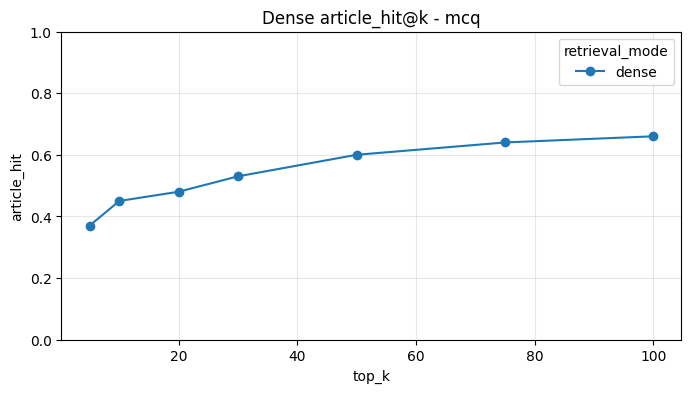

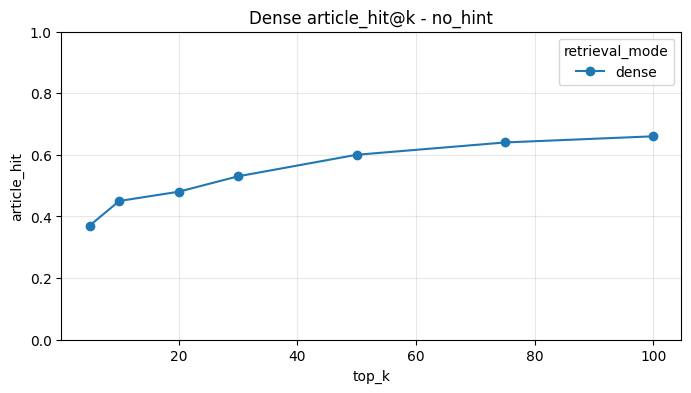

**Breakdown per livello - baseline dense@10 no filter**

,dataset,level,retrieval_mode,filter_name,top_k,questions,article_hit,law_hit,article_mrr,law_only_false_positive_rate
22,mcq,L1,dense,none,10,25,0.36,0.72,0.264444,0.36
50,mcq,L2,dense,none,10,25,0.52,0.76,0.239048,0.24
78,mcq,L3,dense,none,10,25,0.52,0.72,0.420000,0.20
106,mcq,L4,dense,none,10,25,0.40,0.68,0.227444,0.28
134,no_hint,L1,dense,none,10,25,0.36,0.72,0.264444,0.36
162,no_hint,L2,dense,none,10,25,0.52,0.76,0.239048,0.24
190,no_hint,L3,dense,none,10,25,0.52,0.72,0.420000,0.20
218,no_hint,L4,dense,none,10,25,0.40,0.68,0.227444,0.28


In [6]:
direct_cache: dict[tuple, list] = {}


def _direct_key(dataset: str, retrieval_mode: str, top_k: int, filter_name: str, qid: str) -> tuple:
    return (dataset, retrieval_mode, top_k, filter_name, qid)


def _get_direct_candidates(dataset: str, target, *, retrieval_mode: str, top_k: int, filter_name: str, filters: dict):
    key = _direct_key(dataset, retrieval_mode, top_k, filter_name, target.qid)
    if key not in direct_cache:
        direct_cache[key] = retrieve_direct(
            client=qdrant_client,
            collection_name=collection_name,
            embedder=embedder,
            query_text=target.question,
            limit=top_k,
            retrieval_mode=retrieval_mode,
            static_filters=filters,
            rrf_k=CONFIG.rrf_k,
            index_manifest=index_manifest,
        )
    return direct_cache[key]


def _answer_overlap_metrics(target, candidates, *, prefix: str) -> dict[str, Any]:
    expected_articles = set(target.expected_article_ids)
    article_hits = [
        chunk for chunk in candidates
        if str(chunk.payload.get("article_id") or "") in expected_articles
    ]
    overlaps = [answer_overlap(target.correct_answer, chunk.text) for chunk in article_hits]
    return {
        f"{prefix}_expected_article_hit_chunk_count": len(article_hits),
        f"{prefix}_first_article_hit_answer_overlap": overlaps[0] if overlaps else None,
        f"{prefix}_best_expected_article_answer_overlap": max(overlaps) if overlaps else None,
    }


def run_direct_experiment(
    *,
    modes: list[str],
    filter_names: list[str],
    top_k_values: list[int],
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    direct_iter = list(itertools.product(modes, filter_names, top_k_values, all_targets))
    if SHOW_PROGRESS:
        try:
            from tqdm.auto import tqdm
            direct_iter = tqdm(direct_iter, desc="direct experiments")
        except ImportError:
            pass

    for retrieval_mode, filter_name, top_k, (dataset, target) in direct_iter:
        filters = FILTER_VARIANTS[filter_name]
        retrieved = _get_direct_candidates(
            dataset,
            target,
            retrieval_mode=retrieval_mode,
            top_k=top_k,
            filter_name=filter_name,
            filters=filters,
        )
        row = evaluate_candidate_set(
            target=target,
            retrieved=retrieved,
            expanded=[],
            availability=availability,
            retrieval_mode=retrieval_mode,
            top_k=top_k,
            filter_name=filter_name,
            metadata_filters=filters,
        ).to_json_record()
        row["dataset"] = dataset
        row.update(_answer_overlap_metrics(target, retrieved, prefix="direct"))
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_direct(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(["dataset", "retrieval_mode", "filter_name", "top_k"], dropna=False)
        .agg(
            questions=("qid", "nunique"),
            article_hit=("direct_article_hit", "mean"),
            all_expected_articles_hit=("direct_all_expected_articles_hit", "mean"),
            law_hit=("direct_law_hit", "mean"),
            article_mrr=("direct_article_mrr", "mean"),
            law_only_false_positive_rate=("law_only_false_positive", "mean"),
            filter_excluded_rate=("filter_excluded", "mean"),
            avg_best_answer_overlap=("direct_best_expected_article_answer_overlap", "mean"),
        )
        .reset_index()
        .sort_values(["dataset", "retrieval_mode", "filter_name", "top_k"])
    )


def summarize_direct_by_level(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(["dataset", "level", "retrieval_mode", "filter_name", "top_k"], dropna=False)
        .agg(
            questions=("qid", "nunique"),
            article_hit=("direct_article_hit", "mean"),
            law_hit=("direct_law_hit", "mean"),
            article_mrr=("direct_article_mrr", "mean"),
            law_only_false_positive_rate=("law_only_false_positive", "mean"),
        )
        .reset_index()
    )


direct_df = run_direct_experiment(modes=retrieval_modes, filter_names=list(FILTER_VARIANTS), top_k_values=TOP_K_VALUES)
direct_summary = summarize_direct(direct_df)
direct_level_summary = summarize_direct_by_level(direct_df)

mark_experiment("dense_baseline_top10", status="run", rows=int(len(direct_df)))
mark_experiment("dense_topk_curve", status="run", rows=int(len(direct_df)))

baseline_direct = direct_summary[
    (direct_summary["retrieval_mode"] == "dense")
    & (direct_summary["filter_name"] == "none")
].copy()

display_experiment_card(
    "Esperimento A - baseline dense",
    status="run",
    metric="article_hit@k",
    config={"top_k": TOP_K_VALUES, "filter": "none"},
)
display(Markdown(f"Embedding cache: dense={embedder.dense_cache_size}, sparse={embedder.sparse_cache_size}"))
display(baseline_direct)

for dataset in sorted(baseline_direct["dataset"].unique()):
    subset = baseline_direct[baseline_direct["dataset"] == dataset]
    ax = subset.pivot_table(index="top_k", columns="retrieval_mode", values="article_hit").plot(marker="o", figsize=(8, 4))
    ax.set_title(f"Dense article_hit@k - {dataset}")
    ax.set_ylabel("article_hit")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    plt.show()

baseline_by_level = direct_level_summary[
    (direct_level_summary["retrieval_mode"] == "dense")
    & (direct_level_summary["filter_name"] == "none")
    & (direct_level_summary["top_k"] == BASELINE_TOP_K)
].copy()
display(Markdown("**Breakdown per livello - baseline dense@10 no filter**"))
display(baseline_by_level.sort_values(["dataset", "level"]))


## Esperimento B - Filtro metadata

Confronta `none` e `law_status=current` a parita' di `top_k`. Il filtro e' utile solo se migliora il retrieval senza tagliare troppi articoli attesi.


In [7]:
filter_summary = direct_summary[direct_summary["retrieval_mode"] == "dense"].copy()
filter_pivot = filter_summary.pivot_table(
    index=["dataset", "top_k"],
    columns="filter_name",
    values=["article_hit", "law_hit", "article_mrr", "filter_excluded_rate"],
)
filter_pivot.columns = [f"{metric}__{filter_name}" for metric, filter_name in filter_pivot.columns]
filter_pivot = filter_pivot.reset_index()
for filter_name in FILTER_VARIANTS:
    if filter_name == "none" or f"article_hit__{filter_name}" not in filter_pivot.columns:
        continue
    filter_pivot[f"delta_article_hit__{filter_name}_vs_none"] = (
        filter_pivot[f"article_hit__{filter_name}"] - filter_pivot["article_hit__none"]
    )

best_filter_by_dataset_topk = (
    filter_summary.sort_values(
        ["dataset", "top_k", "article_hit", "filter_excluded_rate", "article_mrr", "law_hit"],
        ascending=[True, True, False, True, False, False],
    )
    .groupby(["dataset", "top_k"], group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

mark_experiment("current_law_filter", status="run", rows=int(len(filter_summary)))
mark_experiment("best_filter_from_sweep", status="run", rows=int(len(filter_summary)))
display_experiment_card(
    "Esperimento B - filtri metadata",
    status="run",
    metric="article_hit - filter_excluded",
    config={"filters": list(FILTER_VARIANTS), "top_k": TOP_K_VALUES},
)
display(filter_pivot)
display(Markdown("**Best filter per dataset/top_k**"))
display(best_filter_by_dataset_topk[[
    "dataset", "top_k", "filter_name", "article_hit", "law_hit", "article_mrr", "filter_excluded_rate",
]])

filter_excluded_cases = direct_df[
    (direct_df["retrieval_mode"] == "dense")
    & (direct_df["filter_name"] == PRIMARY_CURRENT_FILTER)
    & (direct_df["top_k"] == BASELINE_TOP_K)
    & (direct_df["filter_excluded"])
].copy()
if filter_excluded_cases.empty:
    display(Markdown(f"_Nessun articolo atteso escluso dal filtro `{PRIMARY_CURRENT_FILTER}` a dense@10._"))
else:
    display(Markdown(f"**Casi in cui `{PRIMARY_CURRENT_FILTER}` esclude l'articolo atteso a dense@10:**"))
    display(filter_excluded_cases[[
        "dataset", "qid", "level", "question", "expected_article_chunk_count", "expected_article_filtered_chunk_count",
    ]])


**Esperimento B - filtri metadata**
- Stato: `run`
- Metrica primaria: `article_hit - filter_excluded`
- Parametri: `filters=['none', 'law_status_current', 'index_views_current', 'article_status_current']`, `top_k=[5, 10, 20, 30, 50, 75, 100]`

,dataset,top_k,article_hit__article_status_current,article_hit__index_views_current,article_hit__law_status_current,article_hit__none,article_mrr__article_status_current,article_mrr__index_views_current,article_mrr__law_status_current,article_mrr__none,filter_excluded_rate__article_status_current,filter_excluded_rate__index_views_current,filter_excluded_rate__law_status_current,filter_excluded_rate__none,law_hit__article_status_current,law_hit__index_views_current,law_hit__law_status_current,law_hit__none,delta_article_hit__law_status_current_vs_none,delta_article_hit__index_views_current_vs_none,delta_article_hit__article_status_current_vs_none
0,mcq,5,0.35,0.35,0.37,0.37,0.257833,0.257833,0.277500,0.277500,0.06,0.1,0.04,0.0,0.61,0.61,0.64,0.64,0.00,-0.02,-0.02
1,mcq,10,0.42,0.41,0.45,0.45,0.266718,0.265718,0.287873,0.287734,0.06,0.1,0.04,0.0,0.70,0.69,0.72,0.72,0.00,-0.04,-0.03
2,mcq,20,0.45,0.45,0.47,0.48,0.268923,0.268423,0.289373,0.290003,0.06,0.1,0.04,0.0,0.76,0.75,0.76,0.77,-0.01,-0.03,-0.03
3,mcq,30,0.49,0.48,0.52,0.53,0.270651,0.269691,0.291383,0.291978,0.06,0.1,0.04,0.0,0.79,0.78,0.79,0.80,-0.01,-0.05,-0.04
4,mcq,50,0.57,0.55,0.59,0.60,0.272722,0.271573,0.293126,0.293675,0.06,0.1,0.04,0.0,0.84,0.82,0.82,0.83,-0.01,-0.05,-0.03
5,mcq,75,0.62,0.60,0.62,0.64,0.273517,0.272350,0.293614,0.294314,0.06,0.1,0.04,0.0,0.87,0.83,0.84,0.87,-0.02,-0.04,-0.02
6,mcq,100,0.63,0.60,0.64,0.66,0.273648,0.272350,0.293868,0.294561,0.06,0.1,0.04,0.0,0.87,0.83,0.84,0.87,-0.02,-0.06,-0.03
7,no_hint,5,0.35,0.35,0.37,0.37,0.257833,0.257833,0.277500,0.277500,0.06,0.1,0.04,0.0,0.61,0.61,0.64,0.64,0.00,-0.02,-0.02
8,no_hint,10,0.42,0.41,0.45,0.45,0.266718,0.265718,0.287873,0.287734,0.06,0.1,0.04,0.0,0.70,0.69,0.72,0.72,0.00,-0.04,-0.03
9,no_hint,20,0.45,0.45,0.47,0.48,0.268923,0.268423,0.289373,0.290003,0.06,0.1,0.04,0.0,0.76,0.75,0.76,0.77,-0.01,-0.03,-0.03


**Best filter per dataset/top_k**

,dataset,top_k,filter_name,article_hit,law_hit,article_mrr,filter_excluded_rate
0,mcq,5,none,0.37,0.64,0.277500,0.0
1,mcq,10,none,0.45,0.72,0.287734,0.0
2,mcq,20,none,0.48,0.77,0.290003,0.0
3,mcq,30,none,0.53,0.80,0.291978,0.0
4,mcq,50,none,0.60,0.83,0.293675,0.0
5,mcq,75,none,0.64,0.87,0.294314,0.0
6,mcq,100,none,0.66,0.87,0.294561,0.0
7,no_hint,5,none,0.37,0.64,0.277500,0.0
8,no_hint,10,none,0.45,0.72,0.287734,0.0
9,no_hint,20,none,0.48,0.77,0.290003,0.0


**Casi in cui `law_status_current` esclude l'articolo atteso a dense@10:**

,dataset,qid,level,question,expected_article_chunk_count,expected_article_filtered_chunk_count
1612,no_hint,eval-0013,L1,Quale organo regionale determina i criteri e le modalità di concessione ed erogazione dei contributi per favorire le produzioni artigian...,12,0
1613,no_hint,eval-0014,L2,Quali delle seguenti produzioni non è una produzione artigianale tipica della Valle d'Aosta?,12,0
1614,no_hint,eval-0015,L3,Una società cooperativa che esercita attività di produzione artigianale tipica ha acquistato materie prime per un importo di 100.000 eur...,9,0
1615,no_hint,eval-0016,L4,Una società cooperativa che esercita attività di produzione artigianale tipica può chiedere un contributo per l'assunzione di un lavorat...,9,0
1712,mcq,eval-0013,L1,Quale organo regionale determina i criteri e le modalità di concessione ed erogazione dei contributi per favorire le produzioni artigian...,12,0
1713,mcq,eval-0014,L2,Quali delle seguenti produzioni non è una produzione artigianale tipica della Valle d'Aosta?,12,0
1714,mcq,eval-0015,L3,Una società cooperativa che esercita attività di produzione artigianale tipica ha acquistato materie prime per un importo di 100.000 eur...,9,0
1715,mcq,eval-0016,L4,Una società cooperativa che esercita attività di produzione artigianale tipica può chiedere un contributo per l'assunzione di un lavorat...,9,0


## Esperimento C - Graph expansion

Lo sweep espande i seed recuperati tramite relazioni esplicite del grafo. Il confronto importante e' `direct_article_hit` vs `post_article_hit`; `expansion_noise_ratio` misura quanto rumore viene aggiunto.


graph experiments:   0%|          | 0/907200 [00:00<?, ?it/s]

**Esperimento C - graph expansion**
- Stato: `run`
- Metrica primaria: `post_article_hit - expansion_noise_ratio`
- Parametri: `relations=['references_only', 'modified_by_only', 'inserted_by_only', 'replacement_only', 'amendment_only', 'default']`, `seed_k=[1, 2, 3]`, `max_chunks_per_law=[1, 2, 3]`, `min_confidence=[0.45, 0.6, 0.8]`

,dataset,retrieval_mode,filter_name,top_k,graph_expansion_seed_k,max_chunks_per_expanded_law,min_edge_confidence,relation_set_name,questions,direct_article_hit,post_article_hit,post_law_hit,post_article_mrr,graph_incremental_hits,expanded_expected_article_hits,expansion_noise_ratio,filter_excluded_rate,delta_vs_direct
4374,mcq,dense,none,100,1,1,0.45,amendment_only,100,0.66,0.66,0.88,0.294561,0,2,0.977528,0.0,0.0
4380,mcq,dense,none,100,1,1,0.60,amendment_only,100,0.66,0.66,0.88,0.294561,0,2,0.977528,0.0,0.0
4381,mcq,dense,none,100,1,1,0.60,default,100,0.66,0.66,0.88,0.294561,0,2,0.977528,0.0,0.0
4392,mcq,dense,none,100,1,2,0.45,amendment_only,100,0.66,0.66,0.88,0.294561,0,2,0.977528,0.0,0.0
4398,mcq,dense,none,100,1,2,0.60,amendment_only,100,0.66,0.66,0.88,0.294561,0,2,0.977528,0.0,0.0
4399,mcq,dense,none,100,1,2,0.60,default,100,0.66,0.66,0.88,0.294561,0,2,0.977528,0.0,0.0
4410,mcq,dense,none,100,1,3,0.45,amendment_only,100,0.66,0.66,0.87,0.294561,0,2,0.977528,0.0,0.0
4416,mcq,dense,none,100,1,3,0.60,amendment_only,100,0.66,0.66,0.87,0.294561,0,2,0.977528,0.0,0.0
4417,mcq,dense,none,100,1,3,0.60,default,100,0.66,0.66,0.87,0.294561,0,2,0.977528,0.0,0.0
4378,mcq,dense,none,100,1,1,0.45,references_only,100,0.66,0.66,0.87,0.294561,0,2,0.979167,0.0,0.0


**Migliore configurazione graph per dataset:**

,dataset,retrieval_mode,filter_name,top_k,graph_expansion_seed_k,max_chunks_per_expanded_law,min_edge_confidence,relation_set_name,questions,direct_article_hit,post_article_hit,post_law_hit,post_article_mrr,graph_incremental_hits,expanded_expected_article_hits,expansion_noise_ratio,filter_excluded_rate,delta_vs_direct
0,mcq,dense,none,100,1,1,0.45,amendment_only,100,0.66,0.66,0.88,0.294561,0,2,0.977528,0.0,0.0
1,no_hint,dense,none,100,1,1,0.45,amendment_only,100,0.66,0.66,0.88,0.294561,0,2,0.977528,0.0,0.0


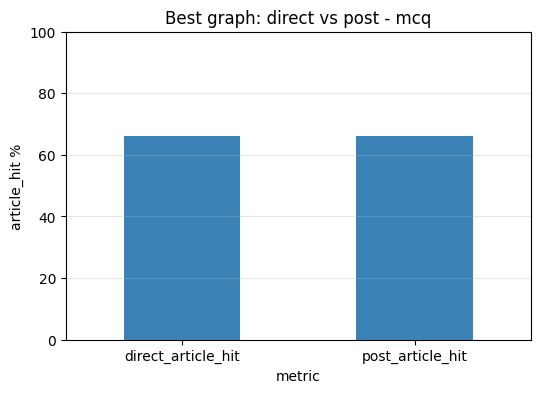

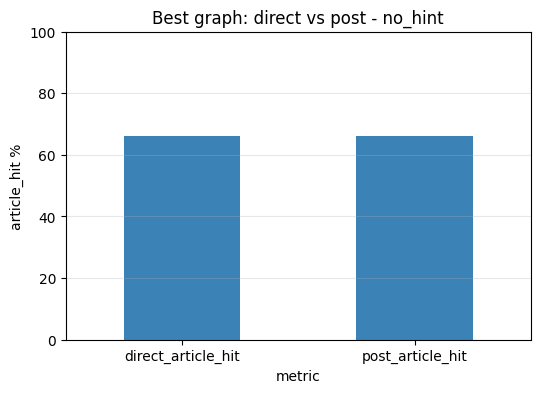

In [8]:
graph_rows: list[dict[str, Any]] = []


def _expand_graph_candidates(
    retrieved,
    target,
    *,
    filters: dict,
    seed_k: int,
    max_chunks_per_law: int,
    min_confidence: float,
    relation_types: list[str],
):
    use_qdrant_ranked = GRAPH_EXPANSION_BACKEND == "qdrant_ranked"
    return expand_with_graph(
        qdrant_client if use_qdrant_ranked else None,
        collection_name=collection_name,
        graph=graph,
        seeds=retrieved[:seed_k],
        relation_types=relation_types,
        static_filters=filters,
        max_chunks_per_law=max_chunks_per_law,
        embedder=embedder if use_qdrant_ranked else None,
        query_text=target.question if use_qdrant_ranked else "",
        max_chunks_total=CONFIG.max_expanded_chunks_total,
        min_edge_confidence=min_confidence,
    )


def run_graph_experiment() -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    graph_iter = list(
        itertools.product(
            retrieval_modes,
            FILTER_VARIANTS.keys(),
            TOP_K_VALUES,
            GRAPH_SEED_K_VALUES,
            MAX_CHUNKS_PER_EXPANDED_LAW_VALUES,
            MIN_EDGE_CONFIDENCE_VALUES,
            RELATION_TYPE_VARIANTS.items(),
            all_targets,
        )
    )
    if SHOW_PROGRESS:
        try:
            from tqdm.auto import tqdm
            graph_iter = tqdm(graph_iter, desc="graph experiments")
        except ImportError:
            pass

    for (
        retrieval_mode,
        filter_name,
        top_k,
        seed_k,
        max_chunks_per_law,
        min_confidence,
        (relation_set_name, relation_types),
        (dataset, target),
    ) in graph_iter:
        filters = FILTER_VARIANTS[filter_name]
        retrieved = _get_direct_candidates(
            dataset,
            target,
            retrieval_mode=retrieval_mode,
            top_k=top_k,
            filter_name=filter_name,
            filters=filters,
        )
        expanded, _relations = _expand_graph_candidates(
            retrieved,
            target,
            filters=filters,
            seed_k=seed_k,
            max_chunks_per_law=max_chunks_per_law,
            min_confidence=min_confidence,
            relation_types=relation_types,
        )
        candidates = dedupe_chunks([*retrieved, *expanded])
        row = evaluate_candidate_set(
            target=target,
            retrieved=retrieved,
            expanded=expanded,
            availability=availability,
            retrieval_mode=retrieval_mode,
            top_k=top_k,
            filter_name=filter_name,
            metadata_filters=filters,
            graph_expansion_enabled=True,
            graph_expansion_seed_k=seed_k,
            max_chunks_per_expanded_law=max_chunks_per_law,
            min_edge_confidence=min_confidence,
        ).to_json_record()
        row["dataset"] = dataset
        row.update(_answer_overlap_metrics(target, retrieved, prefix="direct"))
        row.update(_answer_overlap_metrics(target, candidates, prefix="post"))
        row["relation_set_name"] = relation_set_name
        row["relation_types"] = list(relation_types)
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_graph(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby(
            [
                "dataset", "retrieval_mode", "filter_name", "top_k",
                "graph_expansion_seed_k", "max_chunks_per_expanded_law", "min_edge_confidence", "relation_set_name",
            ],
            dropna=False,
        )
        .agg(
            questions=("qid", "nunique"),
            direct_article_hit=("direct_article_hit", "mean"),
            post_article_hit=("post_article_hit", "mean"),
            post_law_hit=("post_law_hit", "mean"),
            post_article_mrr=("post_article_mrr", "mean"),
            graph_incremental_hits=("graph_incremental_hit", "sum"),
            expanded_expected_article_hits=("expanded_expected_article_hits", "sum"),
            expansion_noise_ratio=("expansion_noise_ratio", "mean"),
            filter_excluded_rate=("filter_excluded", "mean"),
        )
        .reset_index()
    )
    summary["delta_vs_direct"] = summary["post_article_hit"] - summary["direct_article_hit"]
    return summary.sort_values(
        ["dataset", "delta_vs_direct", "graph_incremental_hits", "post_article_hit", "expansion_noise_ratio"],
        ascending=[True, False, False, False, True],
    )


graph_df = run_graph_experiment()
graph_summary = summarize_graph(graph_df)

mark_experiment("graph_default_seed3", status="run", rows=int(len(graph_df)))
mark_experiment("graph_references_only", status="run", rows=int(len(graph_df)))
mark_experiment("best_graph_from_sweep", status="run", rows=int(len(graph_df)))

display_experiment_card(
    "Esperimento C - graph expansion",
    status="run",
    metric="post_article_hit - expansion_noise_ratio",
    config={
        "relations": list(RELATION_TYPE_VARIANTS),
        "seed_k": GRAPH_SEED_K_VALUES,
        "max_chunks_per_law": MAX_CHUNKS_PER_EXPANDED_LAW_VALUES,
        "min_confidence": MIN_EDGE_CONFIDENCE_VALUES,
    },
)
display(graph_summary.head(20))

best_graph_by_dataset = (
    graph_summary.sort_values(
        ["dataset", "delta_vs_direct", "graph_incremental_hits", "post_article_hit", "expansion_noise_ratio"],
        ascending=[True, False, False, False, True],
    )
    .groupby("dataset", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)
display(Markdown("**Migliore configurazione graph per dataset:**"))
display(best_graph_by_dataset)

for dataset in sorted(best_graph_by_dataset["dataset"].unique()):
    row = best_graph_by_dataset[best_graph_by_dataset["dataset"] == dataset].iloc[0]
    plot_df = pd.DataFrame([
        {"metric": "direct_article_hit", "value": row["direct_article_hit"] * 100},
        {"metric": "post_article_hit", "value": row["post_article_hit"] * 100},
    ])
    ax = plot_df.plot.bar(x="metric", y="value", legend=False, rot=0, figsize=(6, 4), color="#3b82b6")
    ax.set_title(f"Best graph: direct vs post - {dataset}")
    ax.set_ylabel("article_hit %")
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.3)
    plt.show()


## Esperimento D - Hybrid preflight

Lo scenario hybrid viene trattato come capability del run: se l'indice non ha sparse vectors, la scelta viene registrata come `skipped`; se sono disponibili, il direct sweep include anche `retrieval_mode=hybrid`.


In [9]:
if hybrid_available:
    hybrid_summary = direct_summary[direct_summary["retrieval_mode"].isin(["dense", "hybrid"])].copy()
    display_experiment_card(
        "Esperimento D - hybrid retrieval",
        status="run",
        metric="article_hit@k",
        note="Hybrid incluso nella stessa griglia del direct sweep.",
    )
    display(hybrid_summary)
else:
    hybrid_summary = pd.DataFrame()
    display_experiment_card(
        "Esperimento D - hybrid retrieval",
        status="skipped",
        metric="article_hit@k",
        note="Sparse vectors non disponibili nell'indice corrente; nessun rebuild viene eseguito nel notebook.",
    )

display(_ordered_columns(experiment_map_df(), ["name", "stage", "primary_metric", "status", "reason", "rows", "parameters"]))


**Esperimento D - hybrid retrieval**
- Stato: `skipped`
- Metrica primaria: `article_hit@k`
- Nota: Sparse vectors non disponibili nell'indice corrente; nessun rebuild viene eseguito nel notebook.

,name,stage,primary_metric,status,reason,rows,parameters,title
0,dense_baseline_top10,direct,article_hit@10,run,,5600.0,"{'retrieval_mode': 'dense', 'top_k': 10, 'filter': 'none'}",Baseline dense@10 senza filtro
1,dense_topk_curve,direct,article_hit@k,run,,5600.0,"{'retrieval_mode': 'dense', 'top_k': [5, 10, 20, 30, 50, 75, 100], 'filter': 'none'}",Curva dense top-k
2,best_dense_budget_top20,direct,article_hit@k con k<=20,pending,NaN,NaN,"{'retrieval_mode': 'dense', 'top_k_max': 20, 'filters': ['none', 'law_status_current', 'index_views_current', 'article_status_current']}",Best direct con budget top20
3,current_law_filter,direct,article_hit@10 - filter_excluded,run,,56.0,"{'retrieval_mode': 'dense', 'top_k': 10, 'filter': 'law_status_current'}",Filtro law_status=current
4,best_filter_from_sweep,direct,article_hit@10 - filter_excluded,run,,56.0,"{'retrieval_mode': 'dense', 'top_k': 10, 'filters': ['none', 'law_status_current', 'index_views_current', 'article_status_current']}",Best filtro metadata dal direct sweep
5,graph_default_seed3,graph,post_article_hit@10,run,,907200.0,"{'top_k': 10, 'seed_k': 3, 'max_chunks_per_law': 2, 'min_confidence': 0.45, 'relations': 'default'}",Graph expansion default
6,graph_references_only,graph,post_article_hit@10,run,,907200.0,"{'top_k': 10, 'seed_k': 3, 'max_chunks_per_law': 2, 'min_confidence': 0.45, 'relations': 'references_only'}",Graph expansion REFERENCES only
7,best_graph_from_sweep,graph,post_article_hit - expansion_noise_ratio,run,,907200.0,{'search_space': 'graph sweep'},Best graph dal sweep
8,best_graph_low_noise,graph,post_article_hit con noise<=0.95,pending,NaN,NaN,{'max_expansion_noise_ratio': 0.95},Best graph low-noise
9,hybrid_if_available,direct,article_hit@k,skipped,Index dense-only: sparse vector missing or embedder lacks sparse embeddings,NaN,"{'retrieval_mode': 'hybrid', 'top_k': [5, 10, 20, 30, 50, 75, 100]}",Hybrid retrieval se disponibile


## Esperimento E - Waterfall finale e conclusione automatica

La tabella finale mette tutti gli scenari nominati sullo stesso contratto. Il vincitore e' scelto per `article_hit_pct`; i tradeoff vengono riportati accanto alla decisione.


,experiment_name,scenario_name,dataset,stage,status,article_hit_pct,law_hit_pct,article_mrr,n_questions,n_filter_excluded,delta_vs_baseline,skip_reason
0,dense_baseline_top10,Baseline dense@10 (no filter),mcq,direct,run,45.0,72.0,0.288,100,0,,
1,dense_topk_curve,Best dense top-k (no filter),mcq,direct,run,66.0,87.0,0.295,100,0,+21.0,
2,best_dense_budget_top20,Best direct budget top20,mcq,direct,run,48.0,77.0,0.290,100,0,+3.0,
3,current_law_filter,+ Filter law_status=current,mcq,direct,run,45.0,72.0,0.288,100,4,+0.0,
4,best_filter_from_sweep,+ Best filter from sweep,mcq,direct,run,45.0,72.0,0.288,100,0,+0.0,
5,graph_default_seed3,+ Graph default seed=3,mcq,graph,run,45.0,74.0,0.288,100,0,+0.0,
6,graph_references_only,+ Graph REFERENCES only,mcq,graph,run,45.0,74.0,0.288,100,0,+0.0,
7,best_graph_from_sweep,+ Best graph from sweep,mcq,graph,run,66.0,88.0,0.295,100,0,+21.0,
8,best_graph_low_noise,+ Best graph low-noise skipped,mcq,graph,skipped,,,,0,0,,No graph configuration with expansion_noise_ratio <= 0.95
9,hybrid_if_available,Hybrid retrieval skipped,mcq,direct,skipped,,,,0,0,,Index dense-only: sparse vector missing or embedder lacks sparse embeddings


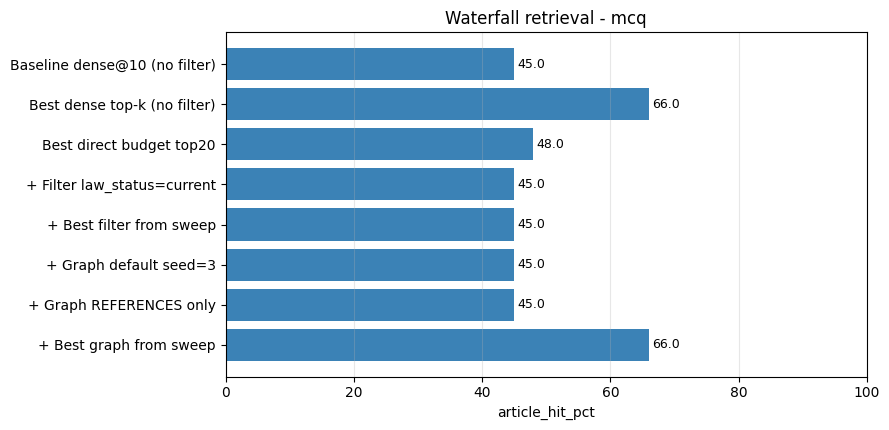

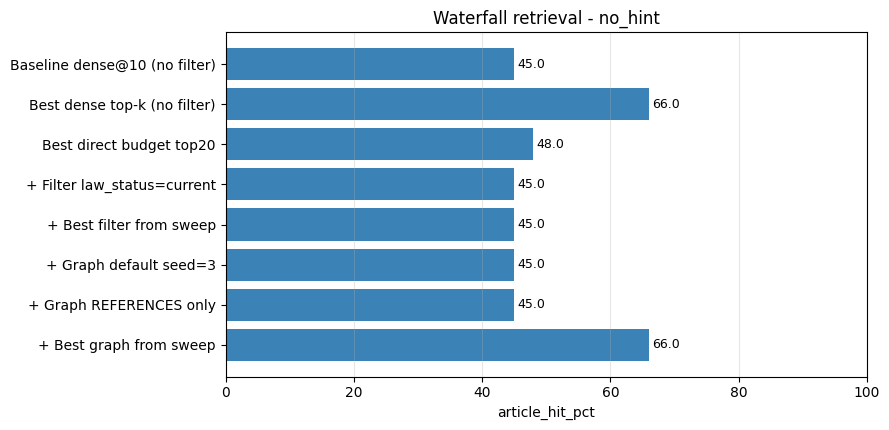

## Conclusione automatica
- **mcq**: vince `+ Best graph from sweep` con `article_hit=66.0%` (`+21.0` punti vs dense@10). Tradeoff: rumore graph medio 0.978; hybrid non valutato per indice dense-only.
- **no_hint**: vince `+ Best graph from sweep` con `article_hit=66.0%` (`+21.0` punti vs dense@10). Tradeoff: rumore graph medio 0.978; hybrid non valutato per indice dense-only.
- Raccomandazione: usare il miglior scenario retrieval-only come candidato per il rerank LLM; se serve dimostrare hybrid, rigenerare prima un indice con sparse vectors fuori da questo notebook.

In [10]:
def summarize_experiment(
    rows: list[dict[str, Any]],
    *,
    experiment_name: str,
    scenario_name: str,
    dataset: str,
    stage: str,
    config: dict[str, Any],
    article_hit_key: str,
    law_hit_key: str,
    article_mrr_key: str,
    baseline_pct: float | None,
    filter_excluded_key: str | None = "filter_excluded",
    status: str = "run",
    skip_reason: str = "",
) -> dict[str, Any]:
    if status != "run":
        return {
            "experiment_name": experiment_name,
            "scenario_name": scenario_name,
            "dataset": dataset,
            "stage": stage,
            "status": status,
            "skip_reason": skip_reason,
            "article_hit_pct": None,
            "law_hit_pct": None,
            "article_mrr": None,
            "n_questions": 0,
            "n_filter_excluded": 0,
            "config": config,
            "delta_vs_baseline": None,
        }
    record = summarize_scenario(
        rows,
        scenario_name=scenario_name,
        dataset=dataset,
        stage=stage,
        config=config,
        article_hit_key=article_hit_key,
        law_hit_key=law_hit_key,
        article_mrr_key=article_mrr_key,
        filter_excluded_key=filter_excluded_key,
        baseline_pct=baseline_pct,
    ).to_json_record()
    record.update({"experiment_name": experiment_name, "status": status, "skip_reason": skip_reason})
    return record


def _direct_rows_for_summary(direct_subset: pd.DataFrame, row: pd.Series) -> list[dict[str, Any]]:
    return direct_subset[
        (direct_subset["retrieval_mode"] == row["retrieval_mode"])
        & (direct_subset["filter_name"] == row["filter_name"])
        & (direct_subset["top_k"] == row["top_k"])
    ].to_dict("records")


def _graph_rows_for_summary(graph_subset: pd.DataFrame, row: pd.Series) -> list[dict[str, Any]]:
    return graph_subset[
        (graph_subset["retrieval_mode"] == row["retrieval_mode"])
        & (graph_subset["filter_name"] == row["filter_name"])
        & (graph_subset["top_k"] == row["top_k"])
        & (graph_subset["graph_expansion_seed_k"] == row["graph_expansion_seed_k"])
        & (graph_subset["max_chunks_per_expanded_law"] == row["max_chunks_per_expanded_law"])
        & (graph_subset["min_edge_confidence"] == row["min_edge_confidence"])
        & (graph_subset["relation_set_name"] == row["relation_set_name"])
    ].to_dict("records")


def _graph_config(row: pd.Series) -> dict[str, Any]:
    return {
        "retrieval_mode": str(row["retrieval_mode"]),
        "filter": str(row["filter_name"]),
        "top_k": int(row["top_k"]),
        "seed_k": int(row["graph_expansion_seed_k"]),
        "max_chunks_per_law": int(row["max_chunks_per_expanded_law"]),
        "min_confidence": float(row["min_edge_confidence"]),
        "relations": str(row["relation_set_name"]),
        "expansion_noise_ratio": None if pd.isna(row["expansion_noise_ratio"]) else float(row["expansion_noise_ratio"]),
    }


scenario_rows: list[dict[str, Any]] = []
datasets_in_run = sorted(target_df["dataset"].unique())

for dataset in datasets_in_run:
    direct_subset = direct_df[direct_df["dataset"] == dataset]
    graph_subset = graph_df[graph_df["dataset"] == dataset]

    baseline_rows = direct_subset[
        (direct_subset["retrieval_mode"] == "dense")
        & (direct_subset["top_k"] == BASELINE_TOP_K)
        & (direct_subset["filter_name"] == "none")
    ].to_dict("records")
    baseline_record = summarize_experiment(
        baseline_rows,
        experiment_name="dense_baseline_top10",
        scenario_name="Baseline dense@10 (no filter)",
        dataset=dataset,
        stage="direct",
        config={"retrieval_mode": "dense", "top_k": BASELINE_TOP_K, "filter": "none"},
        article_hit_key="direct_article_hit",
        law_hit_key="direct_law_hit",
        article_mrr_key="direct_article_mrr",
        baseline_pct=None,
    )
    baseline_pct = baseline_record["article_hit_pct"]
    scenario_rows.append(baseline_record)

    dense_candidates = direct_summary[
        (direct_summary["dataset"] == dataset)
        & (direct_summary["retrieval_mode"] == "dense")
        & (direct_summary["filter_name"] == "none")
    ].sort_values(["article_hit", "article_mrr", "top_k"], ascending=[False, False, True])
    if not dense_candidates.empty:
        best_dense = dense_candidates.iloc[0]
        scenario_rows.append(summarize_experiment(
            _direct_rows_for_summary(direct_subset, best_dense),
            experiment_name="dense_topk_curve",
            scenario_name="Best dense top-k (no filter)",
            dataset=dataset,
            stage="direct",
            config={"retrieval_mode": "dense", "top_k": int(best_dense["top_k"]), "filter": "none"},
            article_hit_key="direct_article_hit",
            law_hit_key="direct_law_hit",
            article_mrr_key="direct_article_mrr",
            baseline_pct=baseline_pct,
        ))

    budget_candidates = direct_summary[
        (direct_summary["dataset"] == dataset)
        & (direct_summary["retrieval_mode"] == "dense")
        & (direct_summary["top_k"] <= BUDGET_TOP_K)
    ].sort_values(
        ["article_hit", "filter_excluded_rate", "article_mrr", "law_hit", "top_k"],
        ascending=[False, True, False, False, True],
    )
    if not budget_candidates.empty:
        best_budget = budget_candidates.iloc[0]
        scenario_rows.append(summarize_experiment(
            _direct_rows_for_summary(direct_subset, best_budget),
            experiment_name="best_dense_budget_top20",
            scenario_name="Best direct budget top20",
            dataset=dataset,
            stage="direct",
            config={"retrieval_mode": "dense", "top_k": int(best_budget["top_k"]), "filter": str(best_budget["filter_name"])},
            article_hit_key="direct_article_hit",
            law_hit_key="direct_law_hit",
            article_mrr_key="direct_article_mrr",
            baseline_pct=baseline_pct,
        ))

    current_candidates = direct_summary[
        (direct_summary["dataset"] == dataset)
        & (direct_summary["retrieval_mode"] == "dense")
        & (direct_summary["top_k"] == BASELINE_TOP_K)
        & (direct_summary["filter_name"] == PRIMARY_CURRENT_FILTER)
    ]
    if not current_candidates.empty:
        current_row = current_candidates.iloc[0]
        scenario_rows.append(summarize_experiment(
            _direct_rows_for_summary(direct_subset, current_row),
            experiment_name="current_law_filter",
            scenario_name="+ Filter law_status=current",
            dataset=dataset,
            stage="direct",
            config={"retrieval_mode": "dense", "top_k": BASELINE_TOP_K, "filter": PRIMARY_CURRENT_FILTER},
            article_hit_key="direct_article_hit",
            law_hit_key="direct_law_hit",
            article_mrr_key="direct_article_mrr",
            baseline_pct=baseline_pct,
        ))

    best_filter_candidates = direct_summary[
        (direct_summary["dataset"] == dataset)
        & (direct_summary["retrieval_mode"] == "dense")
        & (direct_summary["top_k"] == BASELINE_TOP_K)
    ].sort_values(
        ["article_hit", "filter_excluded_rate", "article_mrr", "law_hit"],
        ascending=[False, True, False, False],
    )
    if not best_filter_candidates.empty:
        best_filter = best_filter_candidates.iloc[0]
        scenario_rows.append(summarize_experiment(
            _direct_rows_for_summary(direct_subset, best_filter),
            experiment_name="best_filter_from_sweep",
            scenario_name="+ Best filter from sweep",
            dataset=dataset,
            stage="direct",
            config={"retrieval_mode": "dense", "top_k": BASELINE_TOP_K, "filter": str(best_filter["filter_name"])},
            article_hit_key="direct_article_hit",
            law_hit_key="direct_law_hit",
            article_mrr_key="direct_article_mrr",
            baseline_pct=baseline_pct,
        ))

    graph_default = graph_subset[
        (graph_subset["retrieval_mode"] == "dense")
        & (graph_subset["top_k"] == BASELINE_TOP_K)
        & (graph_subset["filter_name"] == "none")
        & (graph_subset["graph_expansion_seed_k"] == 3)
        & (graph_subset["max_chunks_per_expanded_law"] == 2)
        & (graph_subset["min_edge_confidence"] == 0.45)
        & (graph_subset["relation_set_name"] == "default")
    ].to_dict("records")
    scenario_rows.append(summarize_experiment(
        graph_default,
        experiment_name="graph_default_seed3",
        scenario_name="+ Graph default seed=3",
        dataset=dataset,
        stage="graph",
        config={"top_k": BASELINE_TOP_K, "filter": "none", "seed_k": 3, "max_chunks_per_law": 2, "min_confidence": 0.45, "relations": "default"},
        article_hit_key="post_article_hit",
        law_hit_key="post_law_hit",
        article_mrr_key="post_article_mrr",
        baseline_pct=baseline_pct,
    ))

    graph_refs = graph_subset[
        (graph_subset["retrieval_mode"] == "dense")
        & (graph_subset["top_k"] == BASELINE_TOP_K)
        & (graph_subset["filter_name"] == "none")
        & (graph_subset["graph_expansion_seed_k"] == 3)
        & (graph_subset["max_chunks_per_expanded_law"] == 2)
        & (graph_subset["min_edge_confidence"] == 0.45)
        & (graph_subset["relation_set_name"] == "references_only")
    ].to_dict("records")
    scenario_rows.append(summarize_experiment(
        graph_refs,
        experiment_name="graph_references_only",
        scenario_name="+ Graph REFERENCES only",
        dataset=dataset,
        stage="graph",
        config={"top_k": BASELINE_TOP_K, "filter": "none", "seed_k": 3, "max_chunks_per_law": 2, "min_confidence": 0.45, "relations": "references_only"},
        article_hit_key="post_article_hit",
        law_hit_key="post_law_hit",
        article_mrr_key="post_article_mrr",
        baseline_pct=baseline_pct,
    ))

    best_for_dataset = best_graph_by_dataset[best_graph_by_dataset["dataset"] == dataset]
    if not best_for_dataset.empty:
        best_row_meta = best_for_dataset.iloc[0]
        scenario_rows.append(summarize_experiment(
            _graph_rows_for_summary(graph_subset, best_row_meta),
            experiment_name="best_graph_from_sweep",
            scenario_name="+ Best graph from sweep",
            dataset=dataset,
            stage="graph",
            config=_graph_config(best_row_meta),
            article_hit_key="post_article_hit",
            law_hit_key="post_law_hit",
            article_mrr_key="post_article_mrr",
            baseline_pct=baseline_pct,
        ))

    low_noise_candidates = graph_summary[
        (graph_summary["dataset"] == dataset)
        & (graph_summary["expansion_noise_ratio"].notna())
        & (graph_summary["expansion_noise_ratio"] <= LOW_NOISE_THRESHOLD)
    ].sort_values(
        ["post_article_hit", "delta_vs_direct", "graph_incremental_hits", "expansion_noise_ratio"],
        ascending=[False, False, False, True],
    )
    if low_noise_candidates.empty:
        scenario_rows.append(summarize_experiment(
            [],
            experiment_name="best_graph_low_noise",
            scenario_name="+ Best graph low-noise skipped",
            dataset=dataset,
            stage="graph",
            config={"max_expansion_noise_ratio": LOW_NOISE_THRESHOLD},
            article_hit_key="post_article_hit",
            law_hit_key="post_law_hit",
            article_mrr_key="post_article_mrr",
            baseline_pct=baseline_pct,
            status="skipped",
            skip_reason=f"No graph configuration with expansion_noise_ratio <= {LOW_NOISE_THRESHOLD}",
        ))
    else:
        low_noise_row = low_noise_candidates.iloc[0]
        scenario_rows.append(summarize_experiment(
            _graph_rows_for_summary(graph_subset, low_noise_row),
            experiment_name="best_graph_low_noise",
            scenario_name="+ Best graph low-noise",
            dataset=dataset,
            stage="graph",
            config=_graph_config(low_noise_row),
            article_hit_key="post_article_hit",
            law_hit_key="post_law_hit",
            article_mrr_key="post_article_mrr",
            baseline_pct=baseline_pct,
        ))

    if hybrid_available:
        hybrid_candidates = direct_summary[
            (direct_summary["dataset"] == dataset)
            & (direct_summary["retrieval_mode"] == "hybrid")
        ].sort_values(["article_hit", "article_mrr", "top_k"], ascending=[False, False, True])
        if not hybrid_candidates.empty:
            hybrid_row = hybrid_candidates.iloc[0]
            scenario_rows.append(summarize_experiment(
                _direct_rows_for_summary(direct_subset, hybrid_row),
                experiment_name="hybrid_if_available",
                scenario_name="Hybrid best available",
                dataset=dataset,
                stage="direct",
                config={"retrieval_mode": "hybrid", "top_k": int(hybrid_row["top_k"]), "filter": str(hybrid_row["filter_name"])},
                article_hit_key="direct_article_hit",
                law_hit_key="direct_law_hit",
                article_mrr_key="direct_article_mrr",
                baseline_pct=baseline_pct,
            ))
    else:
        scenario_rows.append(summarize_experiment(
            [],
            experiment_name="hybrid_if_available",
            scenario_name="Hybrid retrieval skipped",
            dataset=dataset,
            stage="direct",
            config={"retrieval_mode": "hybrid"},
            article_hit_key="direct_article_hit",
            law_hit_key="direct_law_hit",
            article_mrr_key="direct_article_mrr",
            baseline_pct=baseline_pct,
            status="skipped",
            skip_reason="Index dense-only: sparse vector missing or embedder lacks sparse embeddings",
        ))

scenarios_df = pd.DataFrame(scenario_rows)
for experiment in EXPERIMENT_MAP:
    name = experiment["name"]
    rows_for_experiment = scenarios_df[scenarios_df["experiment_name"] == name]
    if rows_for_experiment.empty:
        continue
    if (rows_for_experiment["status"] == "run").any():
        mark_experiment(name, status="run", rows=int(len(rows_for_experiment)))
    elif (rows_for_experiment["status"] == "skipped").all():
        mark_experiment(name, status="skipped", reason=str(rows_for_experiment["skip_reason"].dropna().iloc[0] if rows_for_experiment["skip_reason"].notna().any() else ""))

scenario_display = scenarios_df[[
    "experiment_name", "scenario_name", "dataset", "stage", "status", "article_hit_pct", "law_hit_pct",
    "article_mrr", "n_questions", "n_filter_excluded", "delta_vs_baseline", "skip_reason",
]].copy()
display(scenario_display.style.format({
    "article_hit_pct": lambda value: "" if pd.isna(value) else f"{value:.1f}",
    "law_hit_pct": lambda value: "" if pd.isna(value) else f"{value:.1f}",
    "article_mrr": lambda value: "" if pd.isna(value) else f"{value:.3f}",
    "delta_vs_baseline": lambda value: "" if pd.isna(value) else f"{value:+.1f}",
}))

for dataset in datasets_in_run:
    plot_df = scenarios_df[
        (scenarios_df["dataset"] == dataset)
        & (scenarios_df["status"] == "run")
        & (scenarios_df["article_hit_pct"].notna())
    ].copy()
    _plot_barh_metric(plot_df, title=f"Waterfall retrieval - {dataset}")

conclusion_lines = ["## Conclusione automatica"]
for dataset in datasets_in_run:
    subset = scenarios_df[
        (scenarios_df["dataset"] == dataset)
        & (scenarios_df["status"] == "run")
        & (scenarios_df["article_hit_pct"].notna())
    ].copy()
    if subset.empty:
        conclusion_lines.append(f"- **{dataset}**: nessuno scenario eseguito.")
        continue
    baseline = subset[subset["experiment_name"] == "dense_baseline_top10"].iloc[0]
    winner = subset.sort_values(["article_hit_pct", "article_mrr", "law_hit_pct"], ascending=[False, False, False]).iloc[0]
    delta = float(winner["article_hit_pct"] or 0.0) - float(baseline["article_hit_pct"] or 0.0)
    tradeoffs = []
    if int(winner.get("n_filter_excluded") or 0) > 0:
        tradeoffs.append(f"esclude {int(winner['n_filter_excluded'])} target attesi")
    winner_config = winner.get("config") or {}
    if isinstance(winner_config, dict) and winner_config.get("expansion_noise_ratio") is not None:
        tradeoffs.append(f"rumore graph medio {float(winner_config['expansion_noise_ratio']):.3f}")
    if not hybrid_available:
        tradeoffs.append("hybrid non valutato per indice dense-only")
    tradeoff_text = "; ".join(tradeoffs) if tradeoffs else "nessun tradeoff critico emerso nelle metriche disponibili"
    conclusion_lines.append(
        f"- **{dataset}**: vince `{winner['scenario_name']}` con `article_hit={winner['article_hit_pct']:.1f}%` "
        f"(`{delta:+.1f}` punti vs dense@10). Tradeoff: {tradeoff_text}."
    )
conclusion_lines.append("- Raccomandazione: usare il miglior scenario retrieval-only come candidato per il rerank LLM; se serve dimostrare hybrid, rigenerare prima un indice con sparse vectors fuori da questo notebook.")
display(Markdown("\n".join(conclusion_lines)))


## Dashboard Matplotlib - performance per tecnica e parametri

Questa sezione e' pensata per il colpo d'occhio: ogni dataset ha una figura 2x2 che mostra curve direct, scenari nominati, migliori configurazioni graph e tradeoff rumore/guadagno. I label includono i parametri essenziali per leggere subito quale tecnica produce la performance osservata.


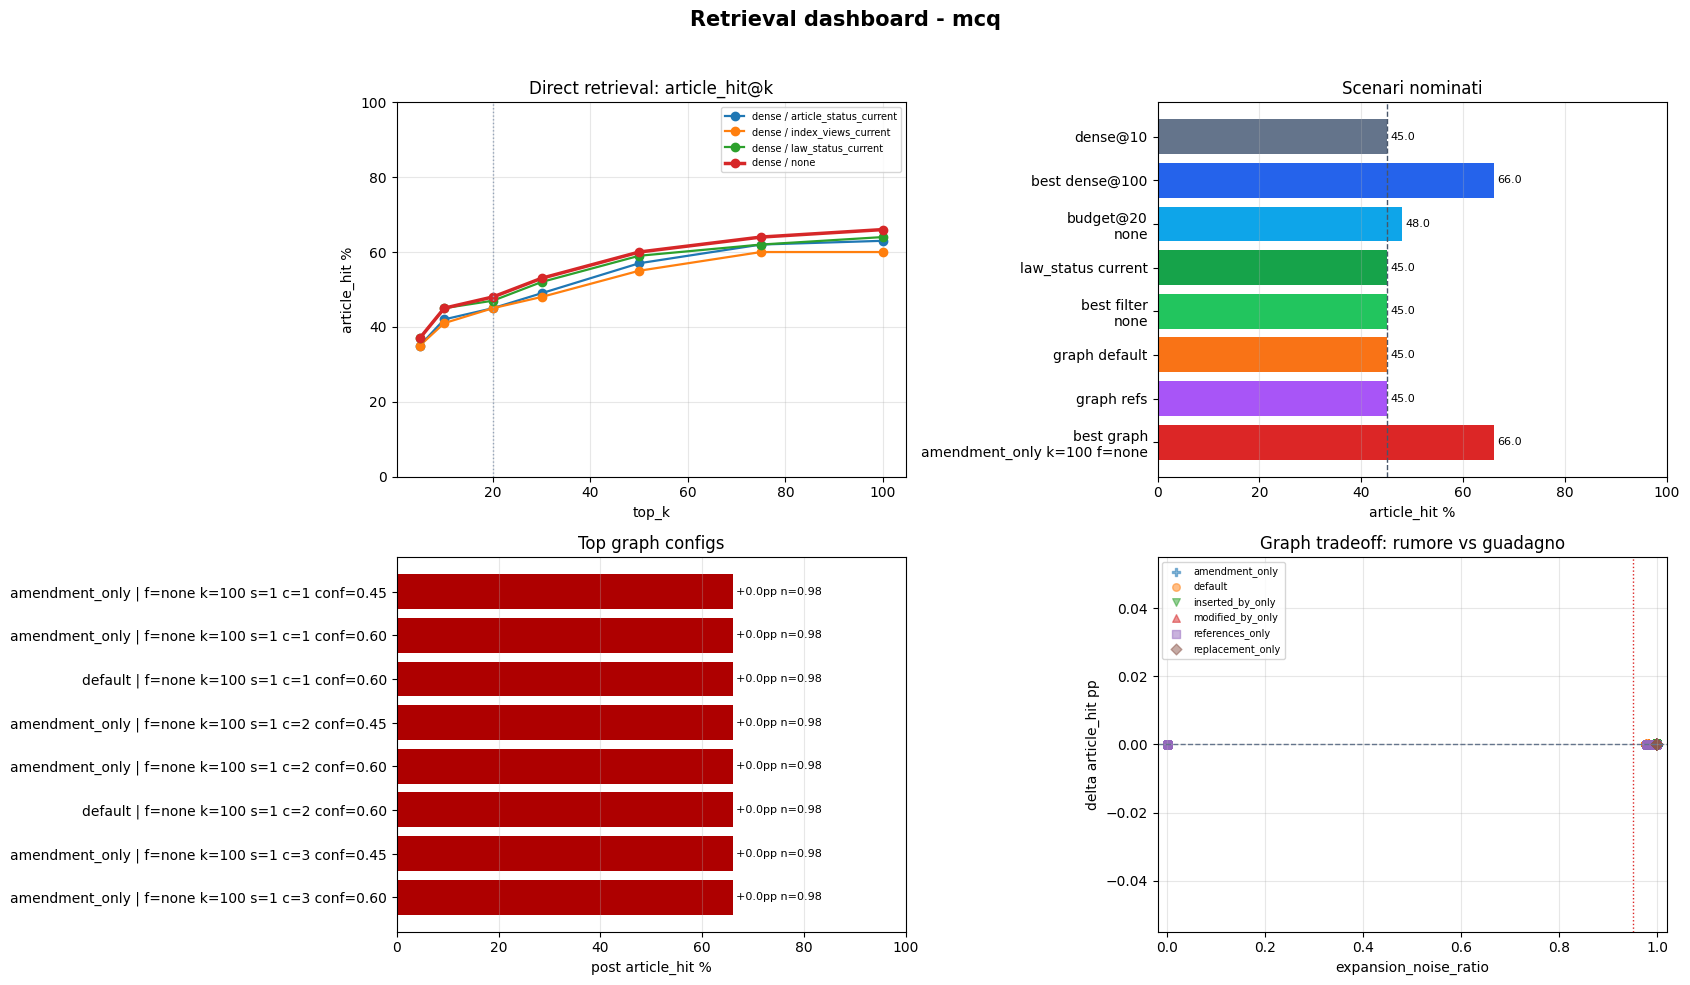

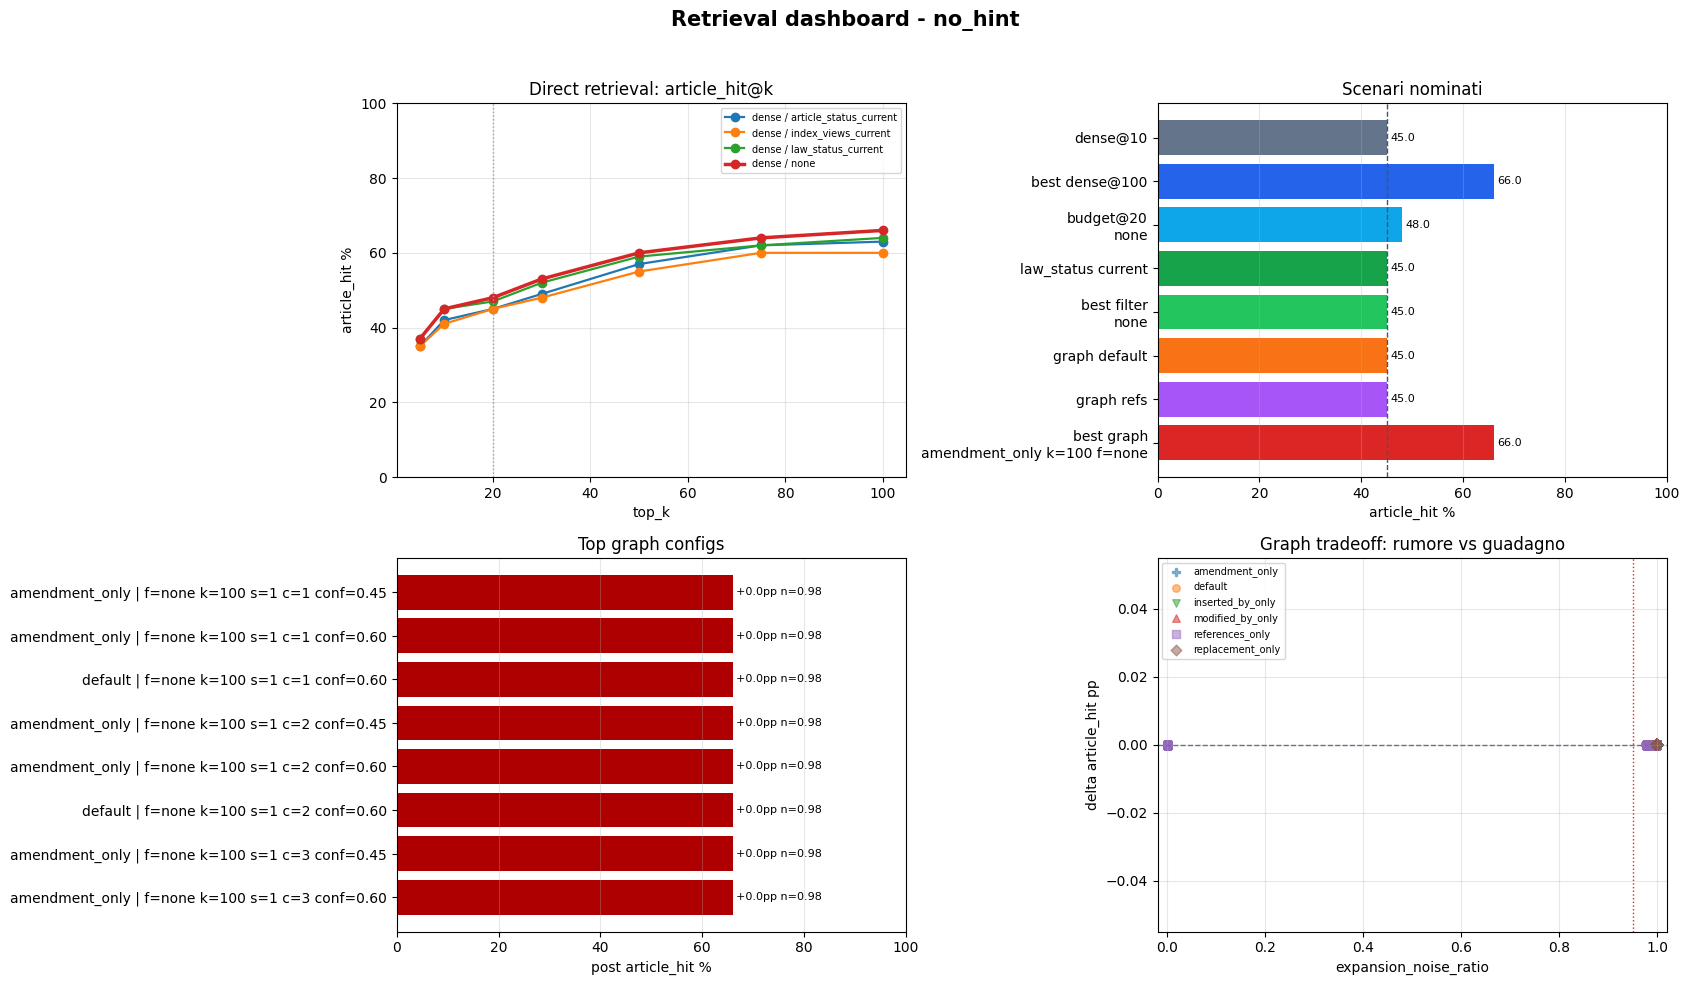

**Sintesi vincitori per dataset**

,dataset,winner,article_hit_pct,delta_vs_dense10
0,mcq,best graph\namendment_only k=100 f=none,66.0,21.0
1,no_hint,best graph\namendment_only k=100 f=none,66.0,21.0


In [11]:
TECHNIQUE_COLORS = {
    "dense_baseline_top10": "#64748b",
    "dense_topk_curve": "#2563eb",
    "best_dense_budget_top20": "#0ea5e9",
    "current_law_filter": "#16a34a",
    "best_filter_from_sweep": "#22c55e",
    "graph_default_seed3": "#f97316",
    "graph_references_only": "#a855f7",
    "best_graph_from_sweep": "#dc2626",
    "best_graph_low_noise": "#7c2d12",
    "hybrid_if_available": "#0891b2",
}
RELATION_MARKERS = {
    "references_only": "s",
    "modified_by_only": "^",
    "inserted_by_only": "v",
    "replacement_only": "D",
    "amendment_only": "P",
    "default": "o",
}


def _short_scenario_label(row: pd.Series) -> str:
    name = str(row["experiment_name"])
    config = row.get("config") or {}
    if name == "dense_baseline_top10":
        return "dense@10"
    if name == "dense_topk_curve":
        return f"best dense@{config.get('top_k', '?')}"
    if name == "best_dense_budget_top20":
        return f"budget@{config.get('top_k', '?')}\n{config.get('filter', '?')}"
    if name == "current_law_filter":
        return "law_status current"
    if name == "best_filter_from_sweep":
        return f"best filter\n{config.get('filter', '?')}"
    if name == "graph_default_seed3":
        return "graph default"
    if name == "graph_references_only":
        return "graph refs"
    if name == "best_graph_from_sweep":
        return f"best graph\n{config.get('relations', '?')} k={config.get('top_k', '?')} f={config.get('filter', '?')}"
    if name == "best_graph_low_noise":
        return f"low-noise graph\n{config.get('relations', '?')} k={config.get('top_k', '?')} f={config.get('filter', '?')}"
    if name == "hybrid_if_available":
        return "hybrid" if row.get("status") == "run" else "hybrid skipped"
    return str(row["scenario_name"])


def _plot_direct_curves(ax, dataset: str) -> None:
    subset = direct_summary[direct_summary["dataset"] == dataset].copy()
    if subset.empty:
        ax.set_axis_off()
        ax.text(0.5, 0.5, "no direct data", ha="center", va="center")
        return
    for (mode, filter_name), group in subset.groupby(["retrieval_mode", "filter_name"]):
        label = f"{mode} / {filter_name}"
        group = group.sort_values("top_k")
        linewidth = 2.5 if filter_name == "none" else 1.6
        ax.plot(group["top_k"], group["article_hit"] * 100, marker="o", linewidth=linewidth, label=label)
    ax.axvline(BUDGET_TOP_K, color="#94a3b8", linestyle=":", linewidth=1)
    ax.set_title("Direct retrieval: article_hit@k")
    ax.set_xlabel("top_k")
    ax.set_ylabel("article_hit %")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)


def _plot_scenario_bars(ax, dataset: str) -> None:
    subset = scenarios_df[
        (scenarios_df["dataset"] == dataset)
        & (scenarios_df["status"] == "run")
        & (scenarios_df["article_hit_pct"].notna())
    ].copy()
    if subset.empty:
        ax.set_axis_off()
        ax.text(0.5, 0.5, "no scenario data", ha="center", va="center")
        return
    subset["label"] = subset.apply(_short_scenario_label, axis=1)
    colors = [TECHNIQUE_COLORS.get(str(name), "#94a3b8") for name in subset["experiment_name"]]
    ax.barh(subset["label"], subset["article_hit_pct"], color=colors)
    baseline_values = subset.loc[subset["experiment_name"] == "dense_baseline_top10", "article_hit_pct"]
    if not baseline_values.empty:
        ax.axvline(float(baseline_values.iloc[0]), color="#475569", linestyle="--", linewidth=1)
    ax.set_title("Scenari nominati")
    ax.set_xlabel("article_hit %")
    ax.set_xlim(0, 100)
    ax.grid(axis="x", alpha=0.3)
    ax.invert_yaxis()
    for index, value in enumerate(subset["article_hit_pct"]):
        ax.text(float(value) + 0.7, index, f"{float(value):.1f}", va="center", fontsize=8)


def _plot_graph_top_configs(ax, dataset: str, top_n: int = 8) -> None:
    subset = graph_summary[graph_summary["dataset"] == dataset].copy()
    if subset.empty:
        ax.set_axis_off()
        ax.text(0.5, 0.5, "no graph data", ha="center", va="center")
        return
    subset = subset.sort_values(
        ["post_article_hit", "delta_vs_direct", "graph_incremental_hits", "expansion_noise_ratio"],
        ascending=[False, False, False, True],
    ).head(top_n).copy()
    subset["label"] = subset.apply(
        lambda row: (
            f"{row['relation_set_name']} | f={row['filter_name']} k={int(row['top_k'])} "
            f"s={int(row['graph_expansion_seed_k'])} c={int(row['max_chunks_per_expanded_law'])} "
            f"conf={float(row['min_edge_confidence']):.2f}"
        ),
        axis=1,
    )
    noise = subset["expansion_noise_ratio"].fillna(0.0).clip(0, 1)
    colors = plt.cm.OrRd(0.25 + 0.65 * noise)
    ax.barh(subset["label"], subset["post_article_hit"] * 100, color=colors)
    ax.set_title("Top graph configs")
    ax.set_xlabel("post article_hit %")
    ax.set_xlim(0, 100)
    ax.grid(axis="x", alpha=0.3)
    ax.invert_yaxis()
    for index, row in enumerate(subset.itertuples(index=False)):
        ax.text(
            float(row.post_article_hit) * 100 + 0.7,
            index,
            f"+{float(row.delta_vs_direct) * 100:.1f}pp n={float(row.expansion_noise_ratio or 0):.2f}",
            va="center",
            fontsize=8,
        )


def _plot_graph_tradeoff(ax, dataset: str) -> None:
    subset = graph_summary[graph_summary["dataset"] == dataset].copy()
    if subset.empty:
        ax.set_axis_off()
        ax.text(0.5, 0.5, "no graph data", ha="center", va="center")
        return
    for relation_set, group in subset.groupby("relation_set_name"):
        marker = RELATION_MARKERS.get(str(relation_set), "o")
        sizes = 30 + group["graph_incremental_hits"].fillna(0).astype(float) * 35
        ax.scatter(
            group["expansion_noise_ratio"].fillna(0.0),
            group["delta_vs_direct"] * 100,
            s=sizes,
            alpha=0.50,
            marker=marker,
            label=str(relation_set),
        )
    ax.axhline(0, color="#64748b", linestyle="--", linewidth=1)
    ax.axvline(LOW_NOISE_THRESHOLD, color="#dc2626", linestyle=":", linewidth=1)
    ax.set_title("Graph tradeoff: rumore vs guadagno")
    ax.set_xlabel("expansion_noise_ratio")
    ax.set_ylabel("delta article_hit pp")
    ax.set_xlim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)


for dataset in datasets_in_run:
    fig, axes = plt.subplots(2, 2, figsize=(17, 10))
    fig.suptitle(f"Retrieval dashboard - {dataset}", fontsize=15, fontweight="bold")
    _plot_direct_curves(axes[0, 0], dataset)
    _plot_scenario_bars(axes[0, 1], dataset)
    _plot_graph_top_configs(axes[1, 0], dataset)
    _plot_graph_tradeoff(axes[1, 1], dataset)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

winner_rows = []
for dataset in datasets_in_run:
    subset = scenarios_df[
        (scenarios_df["dataset"] == dataset)
        & (scenarios_df["status"] == "run")
        & (scenarios_df["article_hit_pct"].notna())
    ].copy()
    if subset.empty:
        continue
    winner = subset.sort_values(["article_hit_pct", "article_mrr", "law_hit_pct"], ascending=[False, False, False]).iloc[0]
    baseline = subset[subset["experiment_name"] == "dense_baseline_top10"].iloc[0]
    winner_rows.append({
        "dataset": dataset,
        "winner": _short_scenario_label(winner),
        "article_hit_pct": float(winner["article_hit_pct"]),
        "delta_vs_dense10": float(winner["article_hit_pct"] - baseline["article_hit_pct"]),
    })

winner_df = pd.DataFrame(winner_rows)
if not winner_df.empty:
    display(Markdown("**Sintesi vincitori per dataset**"))
    display(winner_df)


## Diagnostica errori

Questa sezione conserva viste compatte sui casi che spiegano i fallimenti: legge giusta ma articolo sbagliato, basso overlap lessicale, esclusione da filtro, recuperi e rumore del grafo.


In [12]:
diagnostics_view = direct_df[
    (direct_df["retrieval_mode"] == "dense")
    & (direct_df["filter_name"] == "none")
    & (direct_df["top_k"] == BASELINE_TOP_K)
].copy()

law_only_cases = diagnostics_view[diagnostics_view["law_only_false_positive"]].head(10)
display(Markdown("**Law-only false positives** (top 10):"))
display(law_only_cases[["dataset", "qid", "level", "question", "expected_law_ids", "expected_article_ids"]])

low_overlap_cases = diagnostics_view[
    (diagnostics_view["direct_article_hit"])
    & (diagnostics_view["direct_best_expected_article_answer_overlap"].fillna(0.0) < 0.05)
].head(10)
display(Markdown("**Article-hit con basso overlap testuale con la risposta corretta** (top 10):"))
display(low_overlap_cases[[
    "dataset", "qid", "level", "question", "direct_first_article_rank",
    "direct_expected_article_hit_chunk_count", "direct_best_expected_article_answer_overlap",
]])

if filter_excluded_cases.empty:
    display(Markdown(f"_Nessun caso filter-excluded a dense@10/{PRIMARY_CURRENT_FILTER}._"))
else:
    display(Markdown(f"**Filter-excluded** ({PRIMARY_CURRENT_FILTER} taglia l'articolo atteso, top 10):"))
    display(filter_excluded_cases[["dataset", "qid", "level", "question", "expected_article_chunk_count", "expected_article_filtered_chunk_count"]].head(10))

if not graph_df.empty:
    graph_recovered = graph_df[graph_df["graph_incremental_hit"]].head(10)
    display(Markdown("**Graph recovered** (domande recuperate dall'espansione, top 10):"))
    display(graph_recovered[["dataset", "qid", "relation_set_name", "filter_name", "top_k", "graph_expansion_seed_k", "max_chunks_per_expanded_law", "min_edge_confidence"]])

    noisy_graph = (
        graph_df[graph_df["expansion_noise_ratio"].notna()]
        .sort_values("expansion_noise_ratio", ascending=False)
        .head(10)
    )
    display(Markdown("**Noisy graph** (configurazioni con maggior rumore):"))
    display(noisy_graph[["dataset", "qid", "relation_set_name", "filter_name", "top_k", "graph_expansion_seed_k", "expansion_noise_ratio"]])


**Law-only false positives** (top 10):

,dataset,qid,level,question,expected_law_ids,expected_article_ids
200,no_hint,eval-0001,L1,Quali sono gli organi dell'azienda Usl?,[vda:lr:2000-01-25:5],[vda:lr:2000-01-25:5#art:12]
216,no_hint,eval-0017,L1,"Con quale atto giuridico vengono concessi i contributi per la tutela, la conservazione e la valorizzazione dei borghi in Valle d'Aosta?",[vda:lr:2005-11-18:30],[vda:lr:2005-11-18:30#art:7]
223,no_hint,eval-0024,L4,A quali condizioni è ammessa la pubblicità per le sale da gioco?,[vda:lr:2015-06-15:14],[vda:lr:2015-06-15:14#art:8]
224,no_hint,eval-0025,L1,Quanti anni dura l'autorizzazione alla coltivazione di cave e torbiere?,[vda:lr:2008-03-13:5],[vda:lr:2008-03-13:5#art:9]
225,no_hint,eval-0026,L2,"Con quale atto della Regione viene adottato il PRAE, il Piano Regionale delle attività estrattive?",[vda:lr:2008-03-13:5],[vda:lr:2008-03-13:5#art:4]
227,no_hint,eval-0028,L4,"Nel caso di vendita di una cava, quali sono le autorizzazioni di cui deve munirsi il compratore?",[vda:lr:2008-03-13:5],[vda:lr:2008-03-13:5#art:8]
233,no_hint,eval-0034,L2,Quali prestazioni eroga l’Azienda USL?,[vda:lr:2000-01-25:5],[vda:lr:2000-01-25:5#art:38]
234,no_hint,eval-0035,L3,I soggetti privati possono erogare prestazioni sanitarie?,[vda:lr:2000-01-25:5],[vda:lr:2000-01-25:5#art:38]
237,no_hint,eval-0038,L2,Per quale scopo la Regione ha emanato una legge sul servizio farmaceutico?,[vda:lr:2006-11-06:23],[vda:lr:2006-11-06:23#art:1]
244,no_hint,eval-0045,L1,"Che cosa sono le “piante officinali” ai sensi della Legge regionale 16 febbraio 2011, n. 2?",[vda:lr:2011-02-16:2],[vda:lr:2011-02-16:2#art:1]


**Article-hit con basso overlap testuale con la risposta corretta** (top 10):

,dataset,qid,level,question,direct_first_article_rank,direct_expected_article_hit_chunk_count,direct_best_expected_article_answer_overlap
209,no_hint,eval-0010,L2,"Per effettuare una trasformazione urbanistica o edilizia in Valle d'Aosta, di quale titolo giuridico devo dotarmi?",2.0,2,0.035714
217,no_hint,eval-0018,L2,"Quale organo regionale deve effettuare l'istruttoria sulle domande presentate ai fini della concessione di contributi per la tutela, la ...",10.0,1,0.000000
219,no_hint,eval-0020,L4,"In caso di inadempimento degli obblighi previsti dal provvedimento di concessione, devo restituire l'intero ammontare del contributo ric...",8.0,1,0.000000
226,no_hint,eval-0027,L3,"Quali dei seguenti materiali deve utilizzare una struttura per poter essere qualificata ""stabilimento termale""?",1.0,1,0.000000
229,no_hint,eval-0030,L2,Quali sono le iniziative che la Regione intraprende al fine di prevenire la violenza di genere?,5.0,1,0.000000
238,no_hint,eval-0039,L3,Quali farmaci il cittadino può richiedere quando la farmacia eroga il servizio a battenti chiusi?,1.0,1,0.000000
246,no_hint,eval-0047,L3,Come intende procedere la Regione per favorire lo sviluppo e la qualificazione della produzione regionale delle piante officinali?,3.0,1,0.000000
257,no_hint,eval-0058,L2,"Fino a quale anno è previsto un contributo regionale a sostegno degli eventi di cui alla Legge regionale 29 luglio 2024, n. 14?",5.0,1,0.000000
259,no_hint,eval-0060,L4,"Con quali modalità viene erogato il contributo annuale di cui alla Legge regionale 29 luglio 2024, n. 14?",9.0,1,0.000000
261,no_hint,eval-0062,L2,"Quale ente è competente, a decorrere dal 1° gennaio 2017, al rilascio delle autorizzazioni e delle concessioni nei tratti di strade regi...",1.0,1,0.000000


**Filter-excluded** (law_status_current taglia l'articolo atteso, top 10):

,dataset,qid,level,question,expected_article_chunk_count,expected_article_filtered_chunk_count
1612,no_hint,eval-0013,L1,Quale organo regionale determina i criteri e le modalità di concessione ed erogazione dei contributi per favorire le produzioni artigian...,12,0
1613,no_hint,eval-0014,L2,Quali delle seguenti produzioni non è una produzione artigianale tipica della Valle d'Aosta?,12,0
1614,no_hint,eval-0015,L3,Una società cooperativa che esercita attività di produzione artigianale tipica ha acquistato materie prime per un importo di 100.000 eur...,9,0
1615,no_hint,eval-0016,L4,Una società cooperativa che esercita attività di produzione artigianale tipica può chiedere un contributo per l'assunzione di un lavorat...,9,0
1712,mcq,eval-0013,L1,Quale organo regionale determina i criteri e le modalità di concessione ed erogazione dei contributi per favorire le produzioni artigian...,12,0
1713,mcq,eval-0014,L2,Quali delle seguenti produzioni non è una produzione artigianale tipica della Valle d'Aosta?,12,0
1714,mcq,eval-0015,L3,Una società cooperativa che esercita attività di produzione artigianale tipica ha acquistato materie prime per un importo di 100.000 eur...,9,0
1715,mcq,eval-0016,L4,Una società cooperativa che esercita attività di produzione artigianale tipica può chiedere un contributo per l'assunzione di un lavorat...,9,0


**Graph recovered** (domande recuperate dall'espansione, top 10):

,dataset,qid,relation_set_name,filter_name,top_k,graph_expansion_seed_k,max_chunks_per_expanded_law,min_edge_confidence


**Noisy graph** (configurazioni con maggior rumore):

,dataset,qid,relation_set_name,filter_name,top_k,graph_expansion_seed_k,expansion_noise_ratio
0,no_hint,eval-0001,references_only,none,5,1,1.0
602051,no_hint,eval-0052,amendment_only,index_views_current,50,2,1.0
602053,no_hint,eval-0054,amendment_only,index_views_current,50,2,1.0
602054,no_hint,eval-0055,amendment_only,index_views_current,50,2,1.0
602055,no_hint,eval-0056,amendment_only,index_views_current,50,2,1.0
602056,no_hint,eval-0057,amendment_only,index_views_current,50,2,1.0
602057,no_hint,eval-0058,amendment_only,index_views_current,50,2,1.0
602059,no_hint,eval-0060,amendment_only,index_views_current,50,2,1.0
602060,no_hint,eval-0061,amendment_only,index_views_current,50,2,1.0
602061,no_hint,eval-0062,amendment_only,index_views_current,50,2,1.0


## Persistenza su disco

Salva gli sweep, la waterfall, il manifest e `experiment_map.json`. Il file `sweep_rerank.csv` viene scritto con header anche quando il rerank e' disattivato, cosi' resta leggibile da pandas.


In [13]:
rerank_rows: list[dict[str, Any]] = []
rerank_model_name: str | None = None
rerank_df = pd.DataFrame(rerank_rows)

evaluation_dir = Path(CONFIG.evaluation_dir)
laws_dir = Path(CONFIG.laws_dir)
experiment_records = experiment_map_df().to_dict("records")
manifest = {
    "schema_version": RETRIEVAL_EVALUATION_SCHEMA_VERSION,
    "run_name": RUN_NAME,
    "benchmark_size": BENCHMARK_SIZE,
    "collection_name": collection_name,
    "index_manifest_path": str(index_manifest_path),
    "embedding_model": getattr(base_embedder, "model_name", None),
    "dense_cache_size": embedder.dense_cache_size,
    "sparse_cache_size": embedder.sparse_cache_size,
    "hybrid_available": hybrid_available,
    "retrieval_modes": retrieval_modes,
    "graph_expansion_backend": GRAPH_EXPANSION_BACKEND,
    "n_questions": {dataset: len(targets) for dataset, targets in targets_by_dataset.items()},
    "sweep_dimensions": {
        "top_k": TOP_K_VALUES,
        "filters": list(FILTER_VARIANTS.keys()),
        "graph_seed_k": GRAPH_SEED_K_VALUES,
        "max_chunks_per_law": MAX_CHUNKS_PER_EXPANDED_LAW_VALUES,
        "min_edge_confidence": MIN_EDGE_CONFIDENCE_VALUES,
        "relation_sets": list(RELATION_TYPE_VARIANTS.keys()),
    },
    "rerank": {
        "enabled": RUN_RERANK,
        "model": rerank_model_name,
        "input_k": RERANK_INPUT_K,
        "output_k": RERANK_OUTPUT_K,
        "sample": RERANK_QUESTION_SAMPLE if RUN_RERANK else 0,
    },
    "experiments": experiment_records,
    "source_hashes": {
        "chunks": sha256_file(laws_dir / "chunks.jsonl"),
        "edges": sha256_file(laws_dir / "edges.jsonl"),
        "questions_mcq": sha256_file(evaluation_dir / "questions_mcq.jsonl"),
        "questions_no_hint": sha256_file(evaluation_dir / "questions_no_hint.jsonl"),
        "index_manifest": sha256_file(index_manifest_path),
    },
}

output_path = write_run_artifacts(
    OUTPUT_DIR,
    scenarios=scenarios_df.to_dict("records"),
    sweep_direct=direct_df.to_dict("records"),
    sweep_graph=graph_df.to_dict("records") if not graph_df.empty else [],
    sweep_rerank=rerank_df.to_dict("records") if not rerank_df.empty else [],
    manifest=manifest,
)
write_json(output_path / "experiment_map.json", {
    "schema_version": RETRIEVAL_EVALUATION_SCHEMA_VERSION,
    "run_name": RUN_NAME,
    "created_at": datetime.now(timezone.utc).replace(microsecond=0).isoformat().replace("+00:00", "Z"),
    "experiments": experiment_records,
})

display(Markdown(f"Run salvato in `{output_path}`"))
display(Markdown(f"- scenarios: {len(scenarios_df)} righe"))
display(Markdown(f"- sweep_direct: {len(direct_df)} righe"))
display(Markdown(f"- sweep_graph: {len(graph_df)} righe"))
display(Markdown(f"- sweep_rerank: {len(rerank_df)} righe"))
display(Markdown("- experiment_map: salvata"))


Run salvato in `/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/retrieval_eval_runs/default__20260511T180530Z`

- scenarios: 20 righe

- sweep_direct: 5600 righe

- sweep_graph: 907200 righe

- sweep_rerank: 0 righe

- experiment_map: salvata